### **[SPY–VIX Market Regime Detection and Risk-Aware Trading](https://medium.com/@alexzap922/63a8cf66bd83)**

> *A TICA-Based Deeptime Framework for Regime Detection, Risk Control, and Out-of-Sample Evaluation in Equity Markets*

In [1]:
!pip install -qq deeptime yfinance

import deeptime
print(deeptime.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 8.2 MB/s eta 0:00:00
0.4.5


In [2]:
import sys

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

from deeptime.decomposition import TICA
from deeptime.clustering import KMeans
from deeptime.markov.msm import MaximumLikelihoodMSM

from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1200)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.precision', 4)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['figure.dpi'] = 180

%autosave 20

Autosaving every 20 seconds


#### **Market Regime Detection**

In [3]:
# -------------------------
# Load data
# -------------------------
spy = yf.download("SPY", start="2018-01-01", auto_adjust=True, progress=False)
vix = yf.download("^VIX", start="2018-01-01", auto_adjust=True, progress=False)

df = pd.DataFrame(index=spy.index)
df["price"] = spy["Close"]
df["vix"] = vix["Close"]

df["ret"] = np.log(df["price"]).diff() #log price changes
df["vol"] = df["ret"].rolling(20).std() #Realized volatility
df["vix_chg"] = np.log(df["vix"]).diff() #VIX change

df = df.dropna()
display(df.sample(15))

,price,vix,ret,vol,vix_chg
Date,,,,,
2021-01-19,351.5924,23.2400,0.0078,0.0066,-0.0462
2024-08-01,530.4524,18.5900,-0.0143,0.0099,0.1278
2019-02-05,244.3098,15.5700,0.0042,0.0072,-0.0102
2020-04-29,268.8382,31.2300,0.0258,0.0257,-0.0723
2020-05-20,272.2490,27.9900,0.0168,0.0153,-0.0869
2024-09-17,550.0485,17.6100,0.0004,0.0086,0.0271
2018-08-03,251.0932,11.6400,0.0043,0.0050,-0.0462
2024-12-05,594.4481,13.5400,-0.0016,0.0049,0.0067
2025-02-26,584.5329,19.1000,0.0005,0.0065,-0.0171


In [4]:
# -------------------------
# Features
# -------------------------
X = df[["ret", "vix", "vix_chg", "vol"]].values #Now wee have a multivariate time series.
X = (X - X.mean(axis=0)) / X.std(axis=0)

# -------------------------
# TICA (slow regime)
# -------------------------
tica = TICA(lagtime=20, dim=1)
tica_model = tica.fit_fetch(X)

tic1 = tica_model.transform(X)[:, 0]
df = df.iloc[-len(tic1):].copy()
df["tic1"] = tic1

# -------------------------
# Define regimes
# -------------------------
# simple interpretation:
# TIC1 > 0 → risk-off (bear/stress)
# TIC1 < 0 → risk-on (bull/calm)
df["regime"] = np.where(df["tic1"] > 0, "bear/stress", "bull/calm")
display(df.sample(15))

,price,vix,ret,vol,vix_chg,tic1,regime
Date,,,,,,,
2022-05-05,390.5713,31.2000,-0.0362,0.0189,0.2049,0.7027,bear/stress
2018-08-27,256.5649,12.1600,0.0079,0.0045,0.0141,-0.5501,bull/calm
2023-03-23,377.3776,22.6100,0.0027,0.0116,0.0156,0.2193,bear/stress
2018-10-23,243.3449,20.7100,-0.0051,0.0113,0.0530,0.0529,bear/stress
2026-03-30,630.3461,30.6100,-0.0033,0.0094,-0.0143,0.6193,bear/stress
2022-05-10,376.6780,32.9900,0.0023,0.0197,-0.0520,1.0225,bear/stress
2022-03-02,412.0190,30.7400,0.0182,0.0147,-0.0806,0.8674,bear/stress
2022-01-19,425.0602,23.8500,-0.0104,0.0097,0.0455,0.1776,bear/stress
2025-03-19,557.5842,19.9000,0.0108,0.0130,-0.0866,0.1135,bear/stress


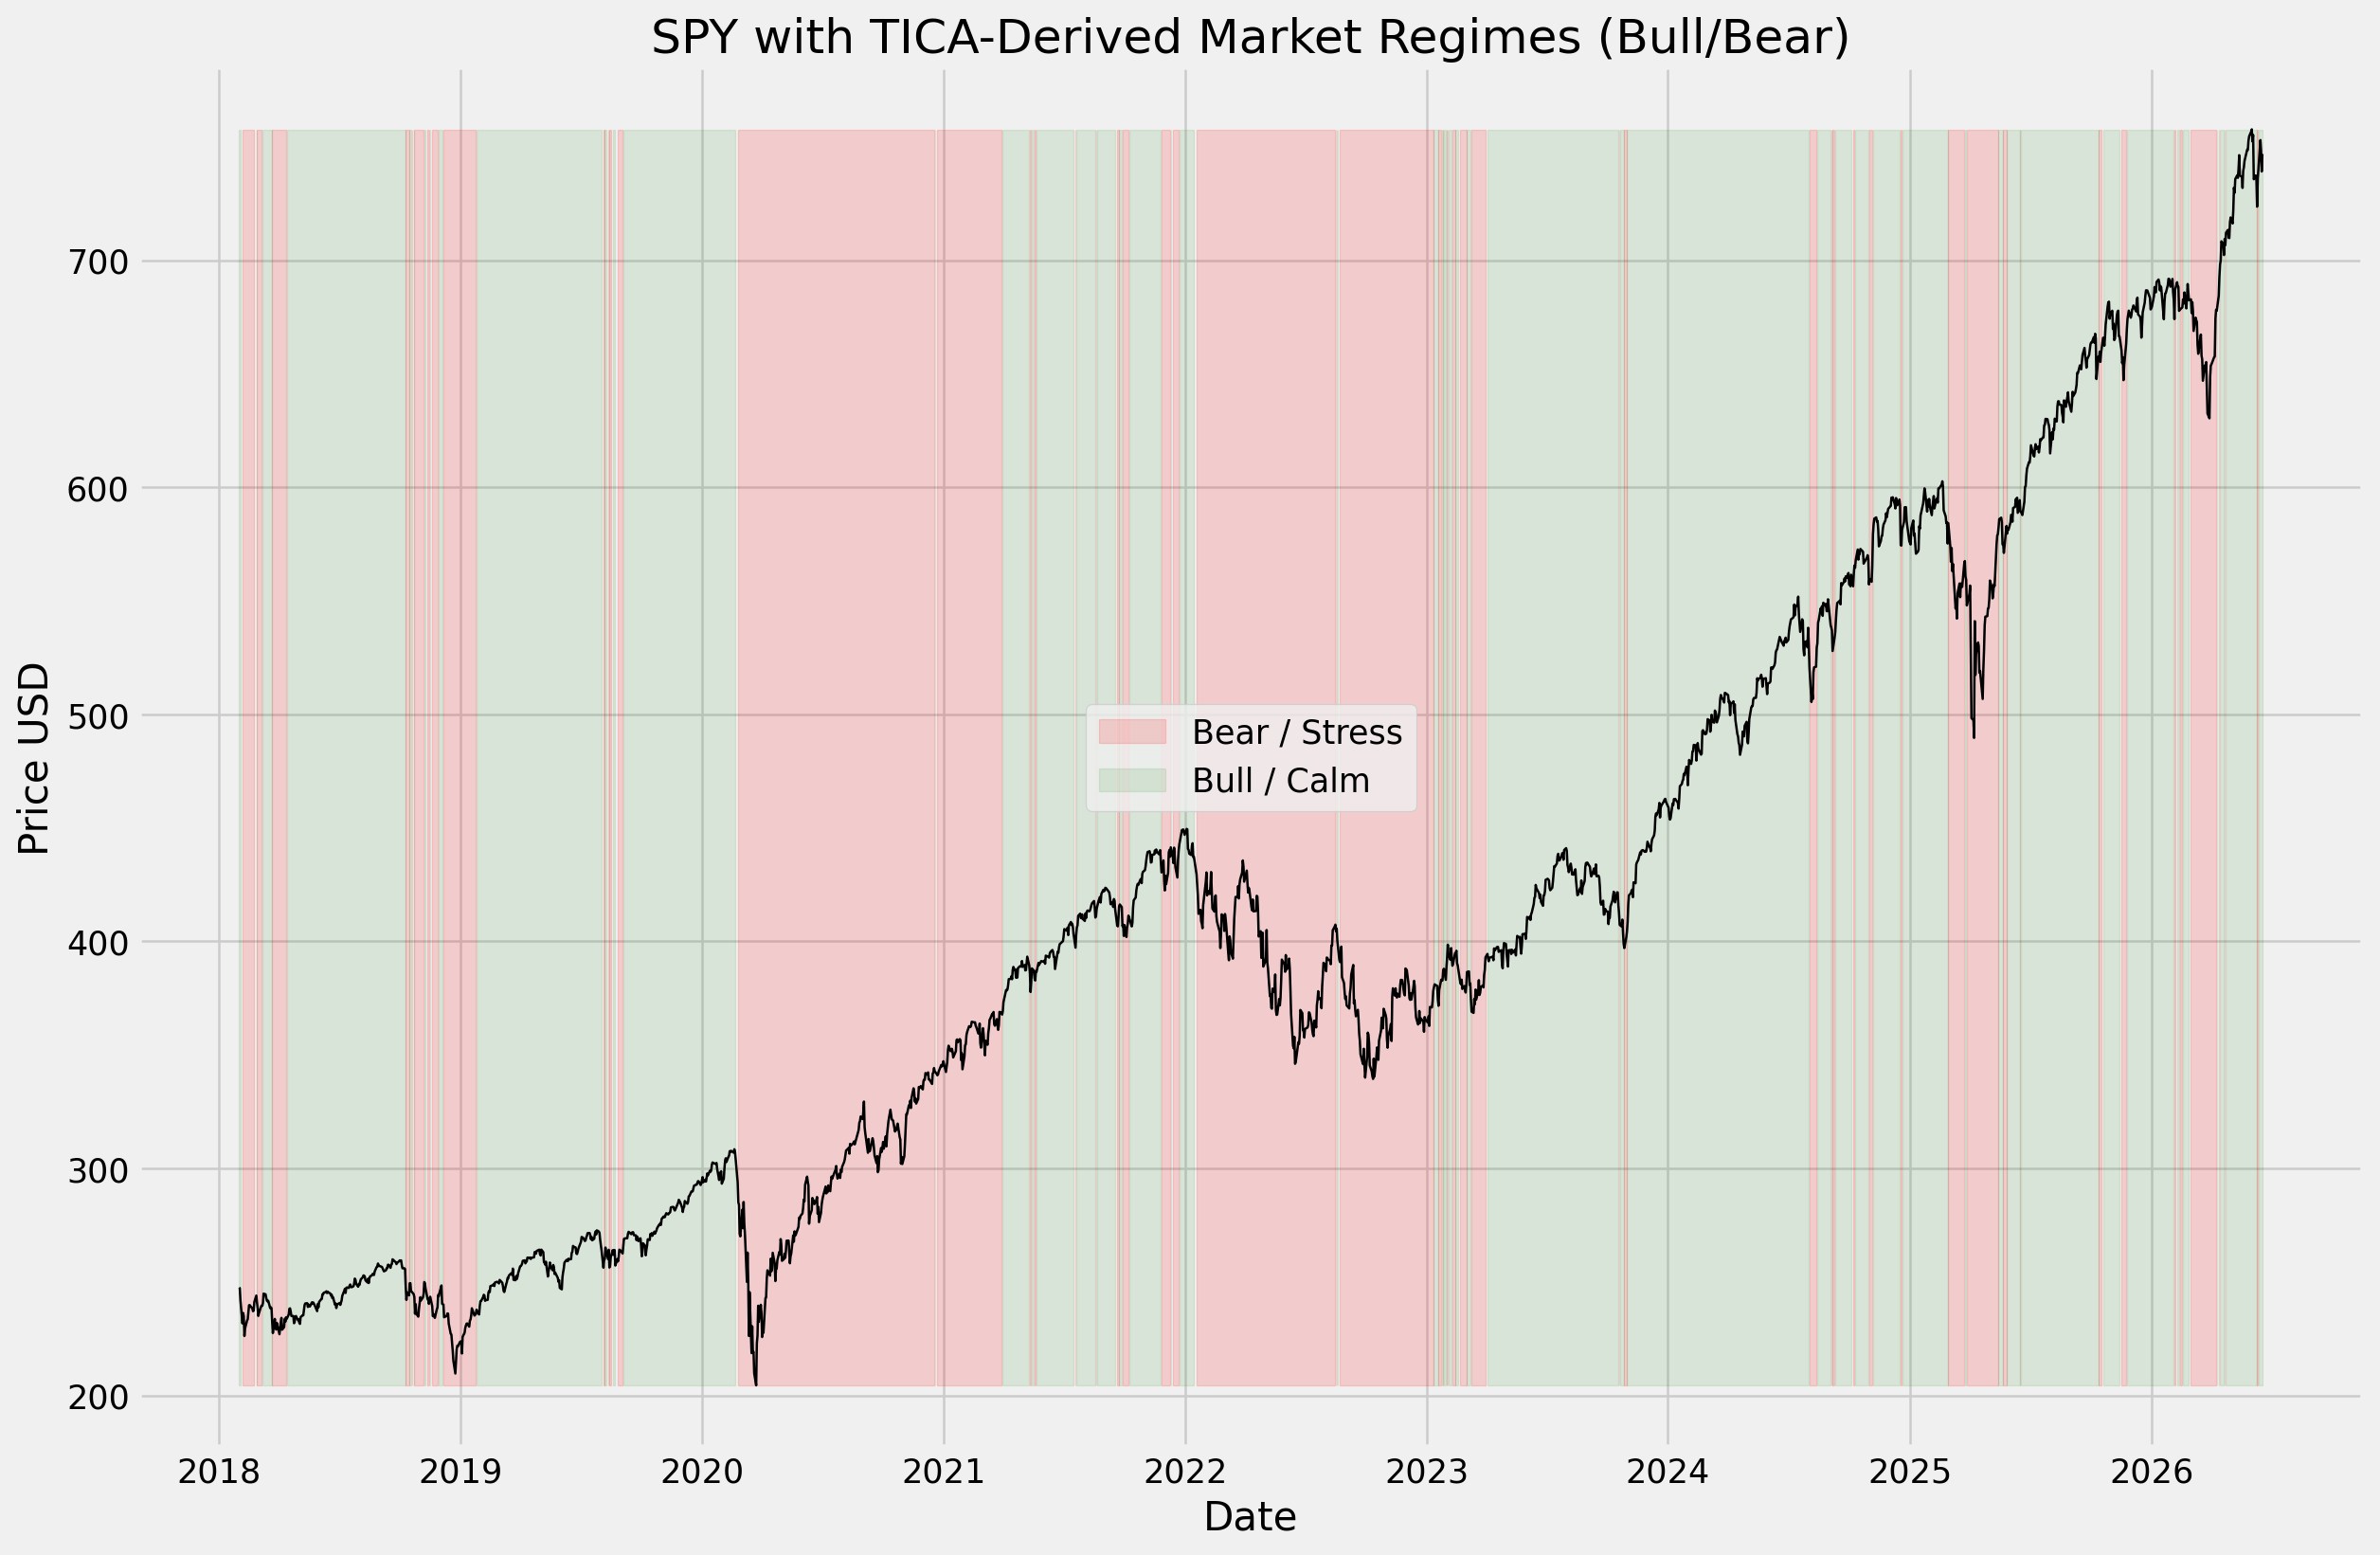

In [5]:
# -------------------------
# Plot SPY with regimes
# -------------------------
plt.figure(figsize=(15, 10))
plt.plot(df.index, df["price"], color="black", linewidth=1)

# shade regimes
plt.fill_between(
  df.index,
  df["price"].min(),
  df["price"].max(),
  where=df["regime"] == "bear/stress",
  color="red",
  alpha=0.15,
  label="Bear / Stress"
)

plt.fill_between(
  df.index,
  df["price"].min(),
  df["price"].max(),
  where=df["regime"] == "bull/calm",
  color="green",
  alpha=0.10,
  label="Bull / Calm"
)

plt.title("SPY with TICA-Derived Market Regimes (Bull/Bear)")
plt.xlabel("Date")
plt.ylabel("Price USD")
plt.legend()
plt.show()

#### **TICA Regime Strategy**

,price,vix,ret,vol,vix_chg,mom,tic1,state,regime_score,ma200,trend_filter,volatility,vol_scale,mom_norm,signal_raw,position,market_ret,strategy_ret,equity,drawdown,buyhold,buyhold_drawdown
Date,,,,,,,,,,,,,,,,,,,,,,
2023-07-10,423.5678,15.0700,0.0025,0.0063,0.0161,0.1487,-0.3568,3,0.5883,383.2195,1.0000,0.0063,159.6806,0.0065,0.1357,1.5000,0.0025,0.0038,2.2432,-0.1205,2.1555,-0.0897
2016-07-13,183.0717,13.0400,-0.0001,0.0126,-0.0384,0.0422,-0.1970,1,0.5491,NaN,0.0000,0.0126,79.5618,-0.7697,-0.6225,NaN,-0.0001,NaN,NaN,NaN,1.0581,-0.0001
2021-06-14,396.1649,16.3900,0.0022,0.0048,0.0462,0.4203,-0.1527,1,0.5381,350.4774,1.0000,0.0048,210.2123,1.9865,1.8553,1.5000,0.0022,0.0029,2.4032,-0.0041,2.0958,0.0000
2022-07-14,358.2282,26.4000,-0.0024,0.0147,-0.0158,-0.1214,0.7326,2,0.3246,410.0929,0.0000,0.0147,67.8833,-1.9626,-2.0696,NaN,-0.0024,NaN,NaN,NaN,1.8567,-0.2158
2021-09-30,402.3725,23.1400,-0.0123,0.0083,0.0254,0.2995,0.1176,4,0.4706,384.4097,1.0000,0.0083,121.1178,1.1056,0.9420,0.7244,-0.0123,-0.0092,2.4290,-0.0523,2.1249,-0.0507
2022-07-12,360.9961,27.2900,-0.0089,0.0172,0.0419,-0.1163,0.7717,2,0.3161,410.6625,0.0000,0.0172,58.2986,-1.9255,-2.0496,NaN,-0.0089,NaN,NaN,NaN,1.8711,-0.2098
2017-09-25,217.4253,10.2100,-0.0020,0.0036,0.0626,0.1758,-0.7036,3,0.6690,206.1230,1.0000,0.0036,278.9692,0.2041,0.4565,1.2142,-0.0020,-0.0026,1.2308,-0.0063,1.2519,-0.0045
2021-12-17,432.7004,21.5700,-0.0107,0.0120,0.0475,0.2572,0.2268,4,0.4435,405.2392,1.0000,0.0120,83.2860,0.7974,0.6229,0.5647,-0.0107,-0.0061,2.5357,-0.0309,2.2803,-0.0199
2017-10-31,224.6050,10.1800,0.0016,0.0032,-0.0310,0.2343,-0.7112,3,0.6707,209.7489,1.0000,0.0032,311.0008,0.6305,0.8466,1.0784,0.0016,0.0017,1.2847,-0.0025,1.2930,-0.0022


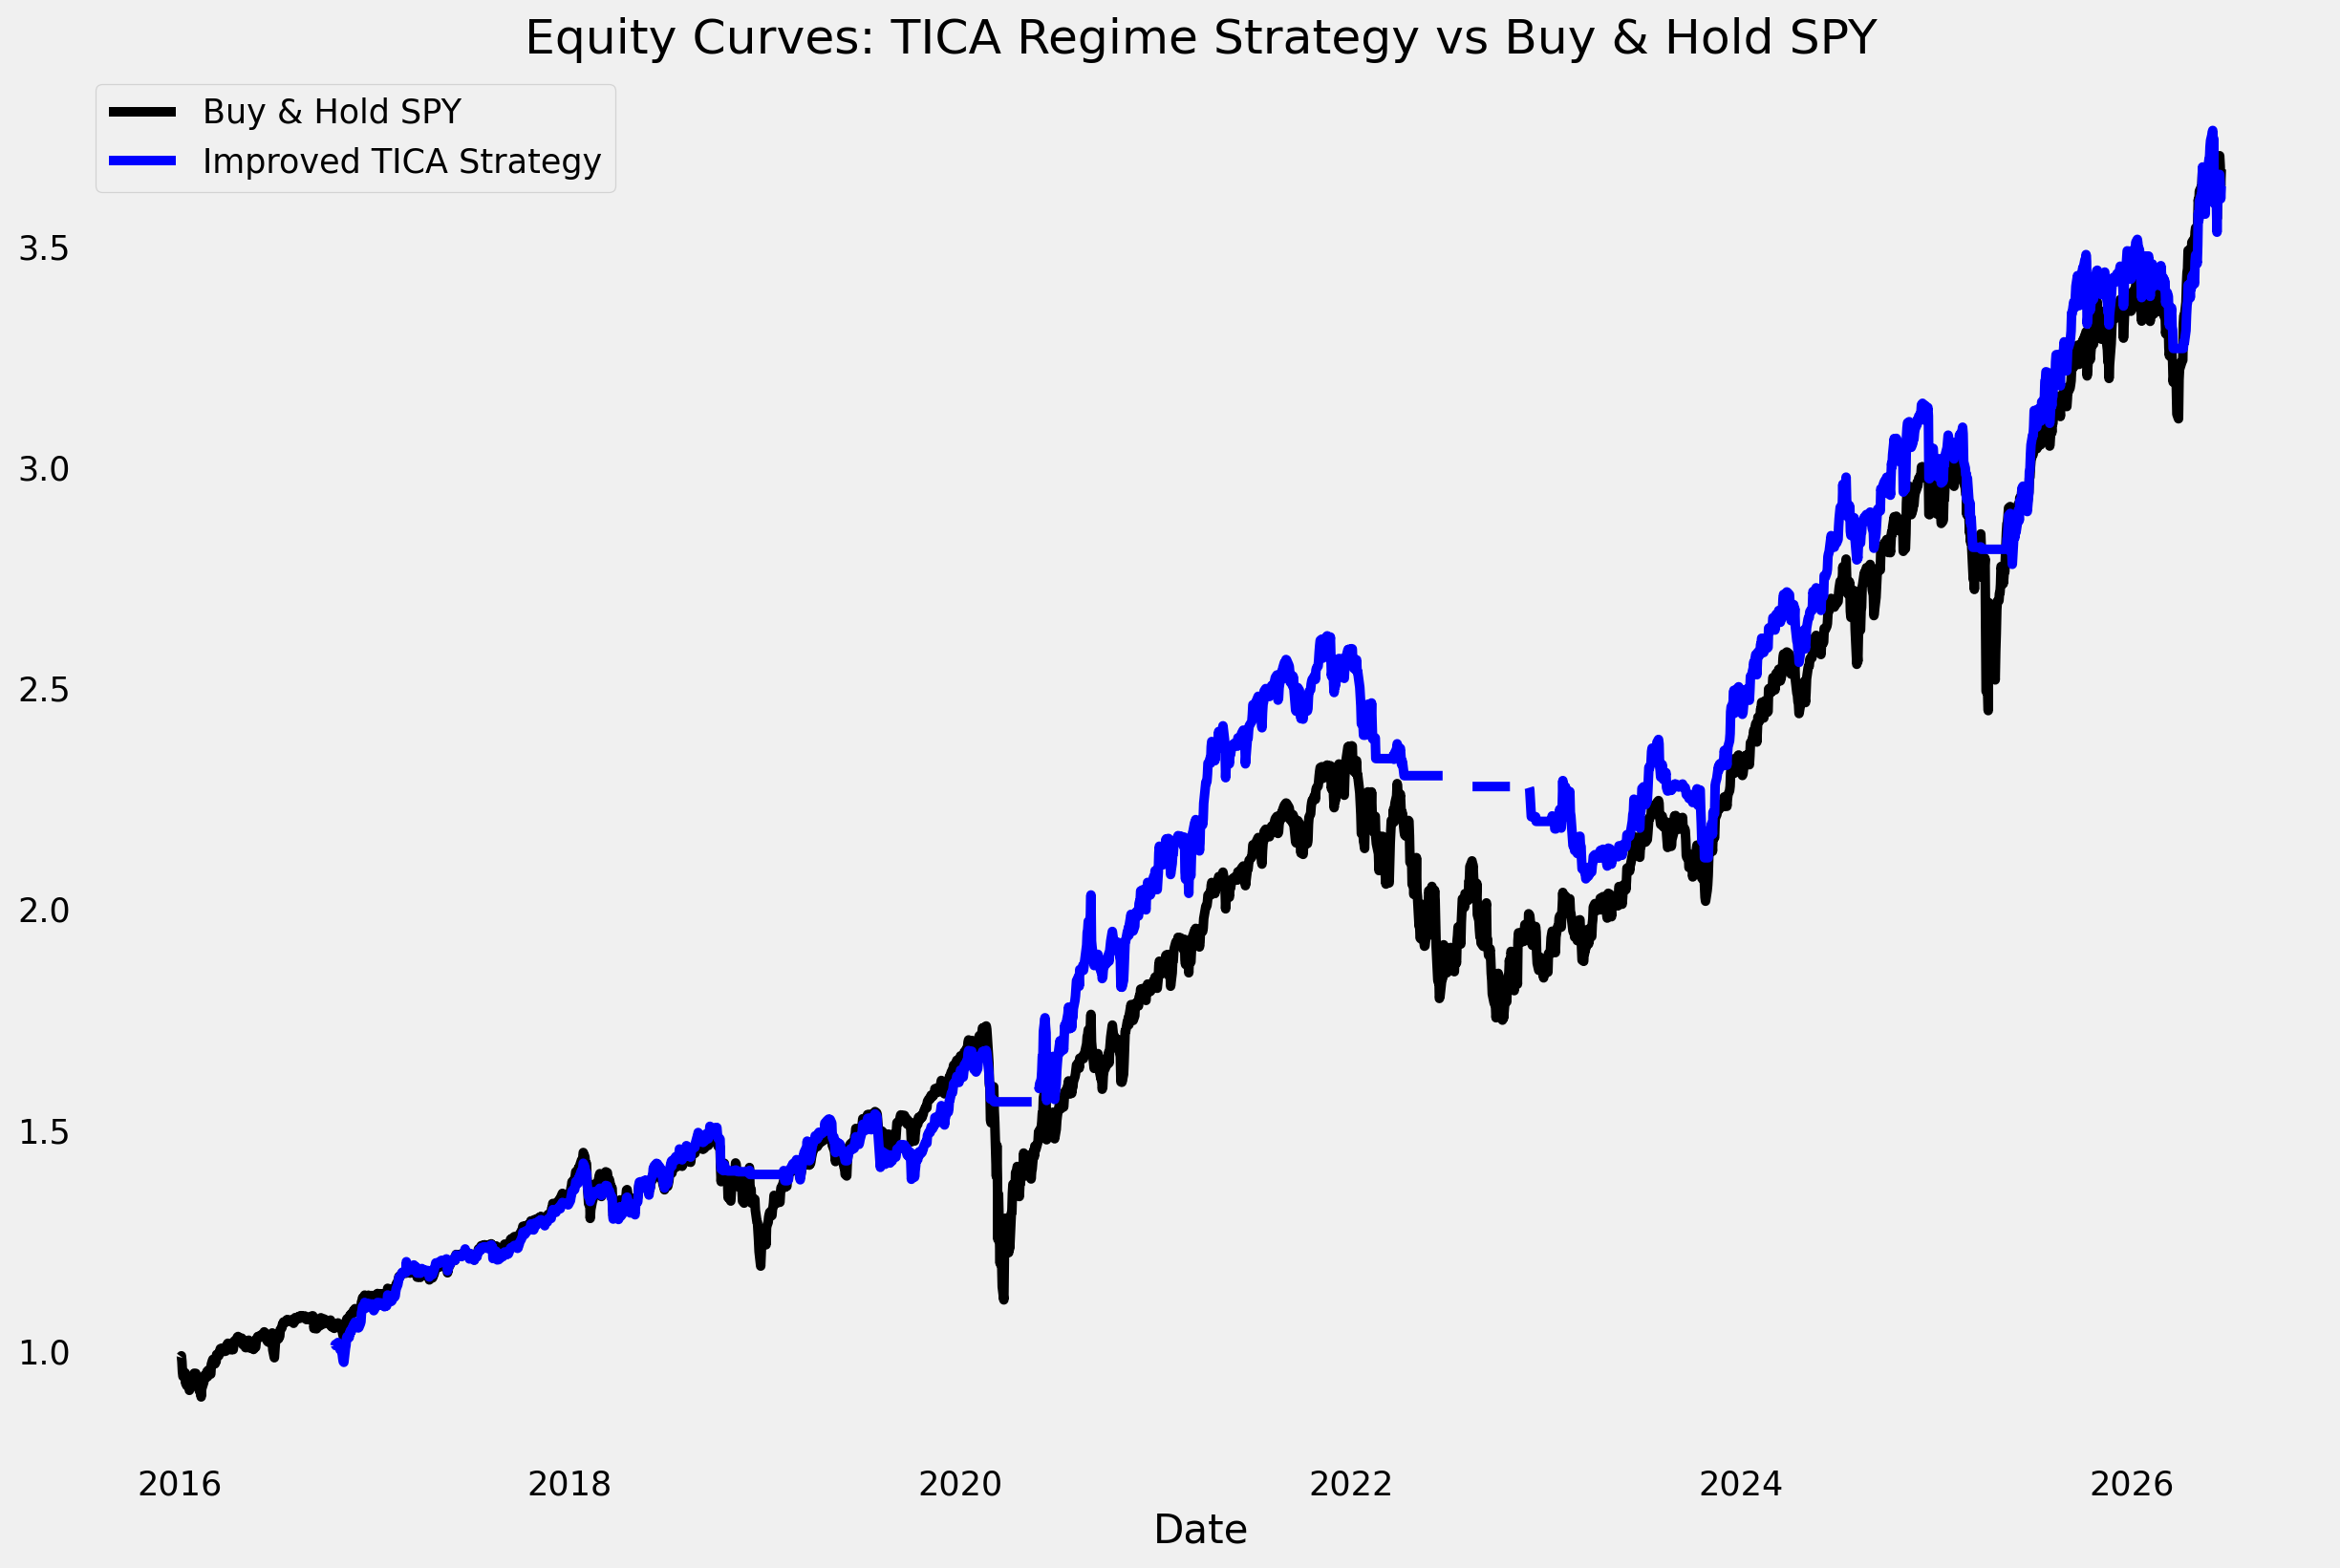

Final Return (Strategy): 3.634175661067034
Final Return (Buy & Hold): 3.672082951044831
Max Drawdown (Strategy): -0.2273512630177451
Max Drawdown (Buy & Hold): -0.3574587248938522


In [6]:
# -----------------------------
# 1. Load data
# -----------------------------
spy = yf.download("SPY", start="2015-01-01", auto_adjust=True, progress=False)
vix = yf.download("^VIX", start="2015-01-01", auto_adjust=True, progress=False)

df = pd.DataFrame(index=spy.index)
df["price"] = spy["Close"]
df["vix"] = vix["Close"]

df["ret"] = np.log(df["price"]).diff()

# -----------------------------
# 2. Features
# -----------------------------
df["vol"] = df["ret"].rolling(20).std()
df["vix_chg"] = np.log(df["vix"]).diff()
df["mom"] = df["price"].pct_change(252)  # momentum

df = df.dropna()

X = df[["ret", "vix", "vix_chg", "vol"]].values
X = (X - X.mean(axis=0)) / X.std(axis=0)

# -----------------------------
# 3. TICA (regime extraction)
# -----------------------------
tica = TICA(lagtime=20, dim=1)
tica_model = tica.fit_fetch(X)

tic1 = tica_model.transform(X)[:, 0]

# smoothing
df = df.iloc[-len(tic1):].copy()
df["tic1"] = pd.Series(tic1, index=df.index).ewm(span=10).mean()

# -----------------------------
# 4. MSM clustering
# -----------------------------
kmeans = KMeans(n_clusters=6)
cluster_model = kmeans.fit_fetch(df[["tic1"]].values)
df["state"] = cluster_model.transform(df[["tic1"]].values)

msm = MaximumLikelihoodMSM(lagtime=20).fit_fetch(df["state"].values)

# -----------------------------
# 5. Core regime signal
# -----------------------------
# soft regime score instead of binary
df["regime_score" ] = 1 / (1 + np.exp(df["tic1"]))

# -----------------------------
# 6. Trend filter
# -----------------------------
df["ma200"] = df["price"].rolling(200).mean()
df["trend_filter"] = (df["price"] > df["ma200"]).astype(float)

# -----------------------------
# 7. Volatility scaling
# -----------------------------
df["volatility"] = df["ret"].rolling(20).std()
df["vol_scale"] = 1 / (df["volatility"] + 1e-6)

# -----------------------------
# 8. Momentum factor
# -----------------------------
df["mom_norm"] = (df["mom"] - df["mom"].mean()) / df["mom"].std()

# -----------------------------
# 9. Combine signals
# -----------------------------
df["signal_raw"] = (
  0.5 * df["regime_score"] +
  0.3 * df["mom_norm"] +
  0.2 * (1 / df["vix"])
)

# normalize signal
df["signal_raw"] = (
  df["signal_raw"] - df["signal_raw"].mean()
) / df["signal_raw"].std()

# -----------------------------
# 10. Hysteresis
# -----------------------------
upper = df["signal_raw"].rolling(10).mean().quantile(0.7)
lower = df["signal_raw"].rolling(10).mean().quantile(0.3)

df["position"] = np.where(
  df["signal_raw"] > upper, 1,
  np.where(df["signal_raw"] < lower, 0.2, np.nan)
)

df["position"] = df["position"].ffill().fillna(0.5)

# -----------------------------
# 11. Combine filters
# -----------------------------
df["position"] *= df["trend_filter"]          # trend filter
df["position"] *= df["vol_scale"]             # vol scaling

# normalize exposure
df["position"] = df["position"] / df["position"].rolling(50).mean()

# cap exposure
df["position"] = df["position"].clip(0, 1.5)

# -----------------------------
# 12. Drawdown protection
# -----------------------------
df["market_ret"] = df["ret"]
df["strategy_ret"] = df["position"].shift(1) * df["market_ret"]

df["equity"] = (1 + df["strategy_ret"]).cumprod()
df["drawdown"] = df["equity"] / df["equity"].cummax() - 1

df.loc[df["drawdown"] < -0.15, "position"] *= 0.5

# recompute final returns
df["strategy_ret"] = df["position"].shift(1) * df["market_ret"]
df["equity"] = (1 + df["strategy_ret"]).cumprod()
df["buyhold"] = (1 + df["market_ret"]).cumprod()
df["buyhold_drawdown"] = df["buyhold"] / df["buyhold"].cummax() - 1

display(df.sample(15))

# -----------------------------
# 13. Plot results
# -----------------------------
plt.figure(figsize=(15,10))

plt.plot(df.index, df["buyhold"], label="Buy & Hold SPY", color="black")
plt.plot(df.index, df["equity"], label="Improved TICA Strategy", color="blue")
plt.xlabel("Date")
plt.title("Equity Curves: TICA Regime Strategy vs Buy & Hold SPY")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 14. Print performance
# -----------------------------

print("Final Return (Strategy):", df["equity"].iloc[-1])
print("Final Return (Buy & Hold):", df["buyhold"].iloc[-1])

print("Max Drawdown (Strategy):", df["drawdown"].min())
print("Max Drawdown (Buy & Hold):", df["buyhold_drawdown"].min())

#### **Strategy Backtesting**

##### **Period-Averaged Static / Full-Sample Metrics**

In [7]:
# -----------------------
# Load data
# -----------------------
spy = yf.download("SPY", start="2015-01-01", auto_adjust=True, progress=False)
vix = yf.download("^VIX", start="2015-01-01", auto_adjust=True, progress=False)

df = pd.DataFrame(index=spy.index)
df["price"] = spy["Close"]
df["vix"] = vix["Close"]

df["ret"] = np.log(df["price"]).diff()
df = df.dropna()

# -----------------------
# Features for TICA
# -----------------------
df["vol"] = df["ret"].rolling(20).std()
df["vix_chg"] = np.log(df["vix"]).diff()

df = df.dropna()

X = df[["ret", "vix", "vix_chg", "vol"]].values
X = (X - X.mean(axis=0)) / X.std(axis=0)

# -----------------------
# TICA regime
# -----------------------
tica = TICA(lagtime=20, dim=1)
tica_model = tica.fit_fetch(X)

tic1 = tica_model.transform(X)[:, 0]

df = df.iloc[-len(tic1):].copy()
df["tic1"] = tic1

# -----------------------
# Strategy signal (improved)
# -----------------------
df["signal"] = 1 / (1 + np.exp(df["tic1"]))  # continuous position

# -----------------------
# Returns
# -----------------------
df["market_ret"] = df["ret"]
df["strategy_ret"] = df["signal"].shift(1) * df["market_ret"]

df = df.dropna()

# -----------------------
# Equity curves
# -----------------------
df["equity_strategy"] = (1 + df["strategy_ret"]).cumprod()
df["equity_buyhold"] = (1 + df["market_ret"]).cumprod()

# -----------------------
# METRICS
# -----------------------

def cagr(series):
    n_years = len(series) / 252
    return series.iloc[-1] ** (1 / n_years) - 1

def sharpe(r):
    return np.sqrt(252) * r.mean() / r.std()

def sortino(r):
    downside = r[r < 0]
    return np.sqrt(252) * r.mean() / downside.std()

def max_dd(equity):
    peak = equity.cummax()
    dd = equity / peak - 1
    return dd.min()

def omega_ratio(r, threshold=0):
    gains = r[r > threshold].sum()
    losses = -r[r < threshold].sum()
    return gains / losses

def win_rate(r):
    return (r > 0).mean()

def kelly(r):
    p = win_rate(r)
    b = r[r > 0].mean() / (-r[r < 0].mean())
    return p - (1 - p) / b

# -----------------------
# Results
# -----------------------
metrics = pd.DataFrame({
  "Strategy": [
    "TICA Strategy",
    "Buy & Hold"
  ],
  "CAGR": [
    cagr(df["equity_strategy"]),
    cagr(df["equity_buyhold"])
  ],
  "Sharpe": [
    sharpe(df["strategy_ret"]),
    sharpe(df["market_ret"])
  ],
  "Sortino": [
    sortino(df["strategy_ret"]),
    sortino(df["market_ret"])
  ],
  "Max Drawdown": [
    max_dd(df["equity_strategy"]),
    max_dd(df["equity_buyhold"])
  ],
  "Omega": [
    omega_ratio(df["strategy_ret"]),
    omega_ratio(df["market_ret"])
  ],
  "Win Rate": [
    win_rate(df["strategy_ret"]),
    win_rate(df["market_ret"])
  ],
  "Kelly": [
    kelly(df["strategy_ret"]),
    kelly(df["market_ret"])
  ]
})

display(metrics)

,Strategy,CAGR,Sharpe,Sortino,Max Drawdown,Omega,Win Rate,Kelly
0,TICA Strategy,0.0547,0.8233,1.0553,-0.1198,1.1497,0.5491,0.0693
1,Buy & Hold,0.1233,0.7460,0.8882,-0.3575,1.1551,0.5491,0.0715


#### **Rolling Sharpe Ratio**

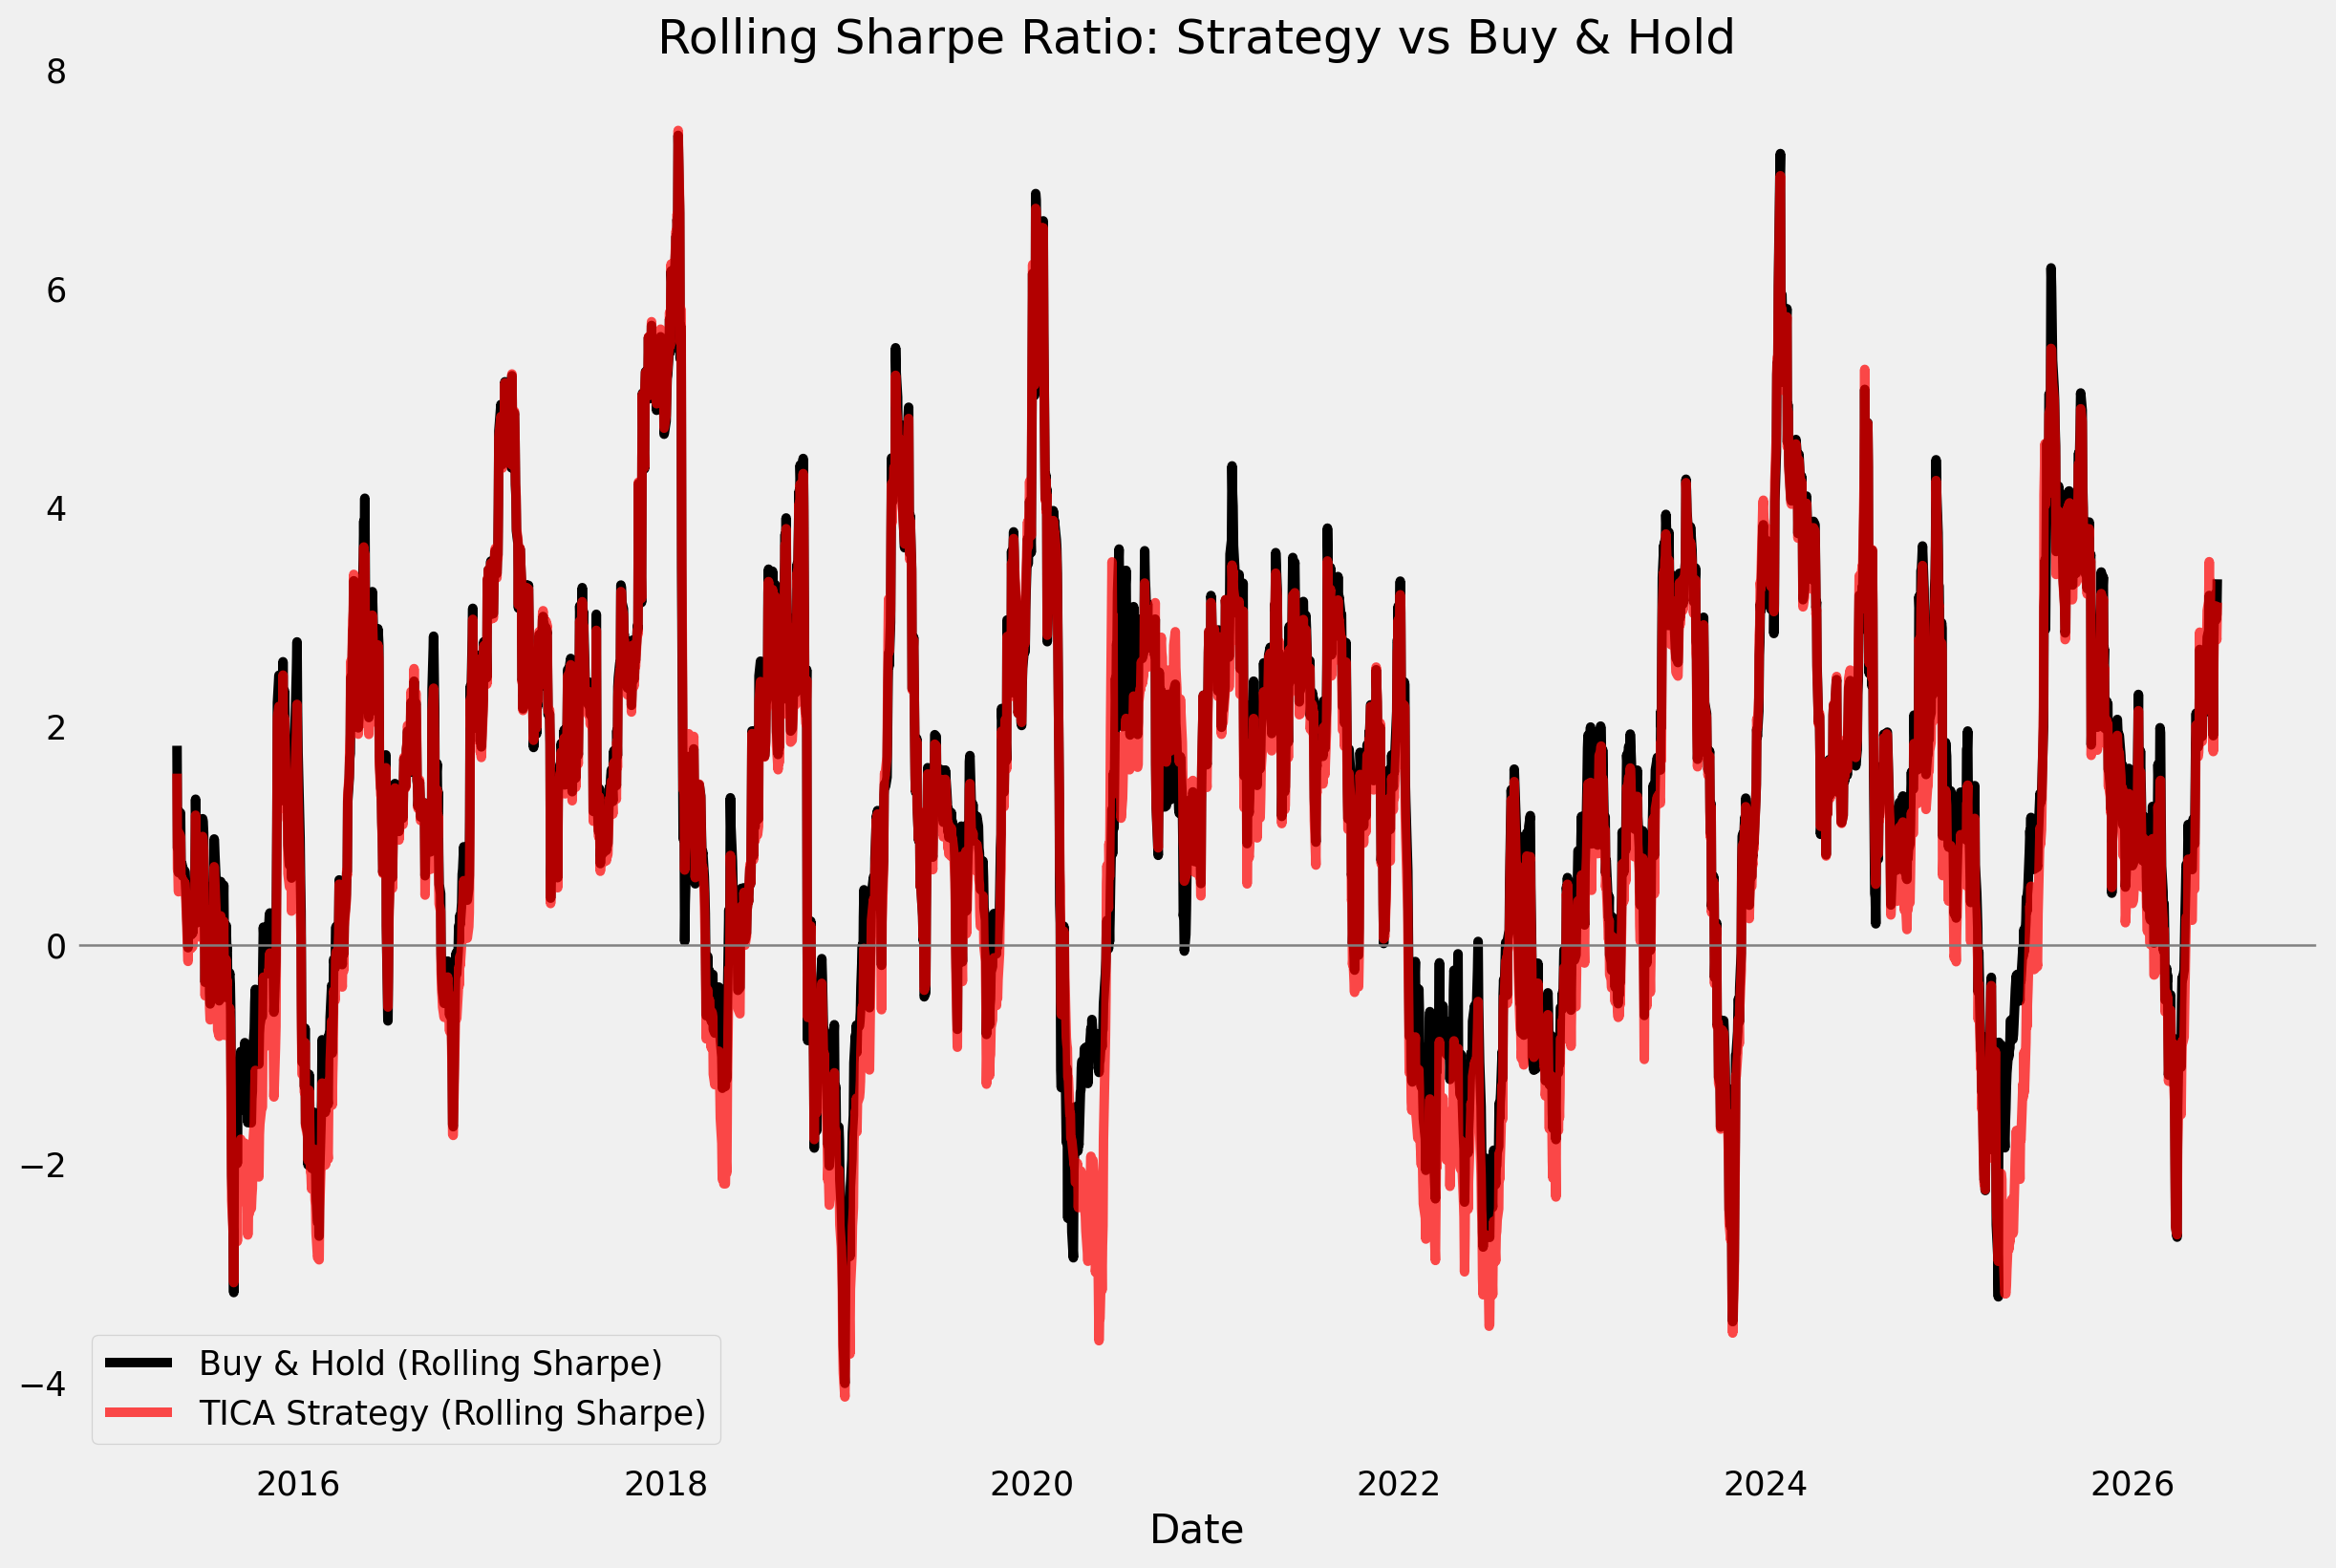

In [8]:
# -----------------------
# Rolling Sharpe function
# -----------------------
def rolling_sharpe(r, window=63):  # ~3 months
  return (
    r.rolling(window)
      .mean()
      / r.rolling(window)
      .std()
  ) * np.sqrt(252)

df["sharpe_strategy"] = rolling_sharpe(df["strategy_ret"])
# Fixed: using 'market_ret' as defined in the previous cell
df["sharpe_buyhold"] = rolling_sharpe(df["market_ret"])

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(15,10))

plt.plot(df.index, df["sharpe_buyhold"], label="Buy & Hold (Rolling Sharpe)", color="black")
plt.plot(df.index, df["sharpe_strategy"], label="TICA Strategy (Rolling Sharpe)", color="red", alpha=0.7)

plt.axhline(0, color="gray", linewidth=1)

plt.title("Rolling Sharpe Ratio: Strategy vs Buy & Hold")
plt.legend()
plt.xlabel("Date")
plt.grid()
plt.show()

##### **Rolling Maximum Drawdown & Volatility**

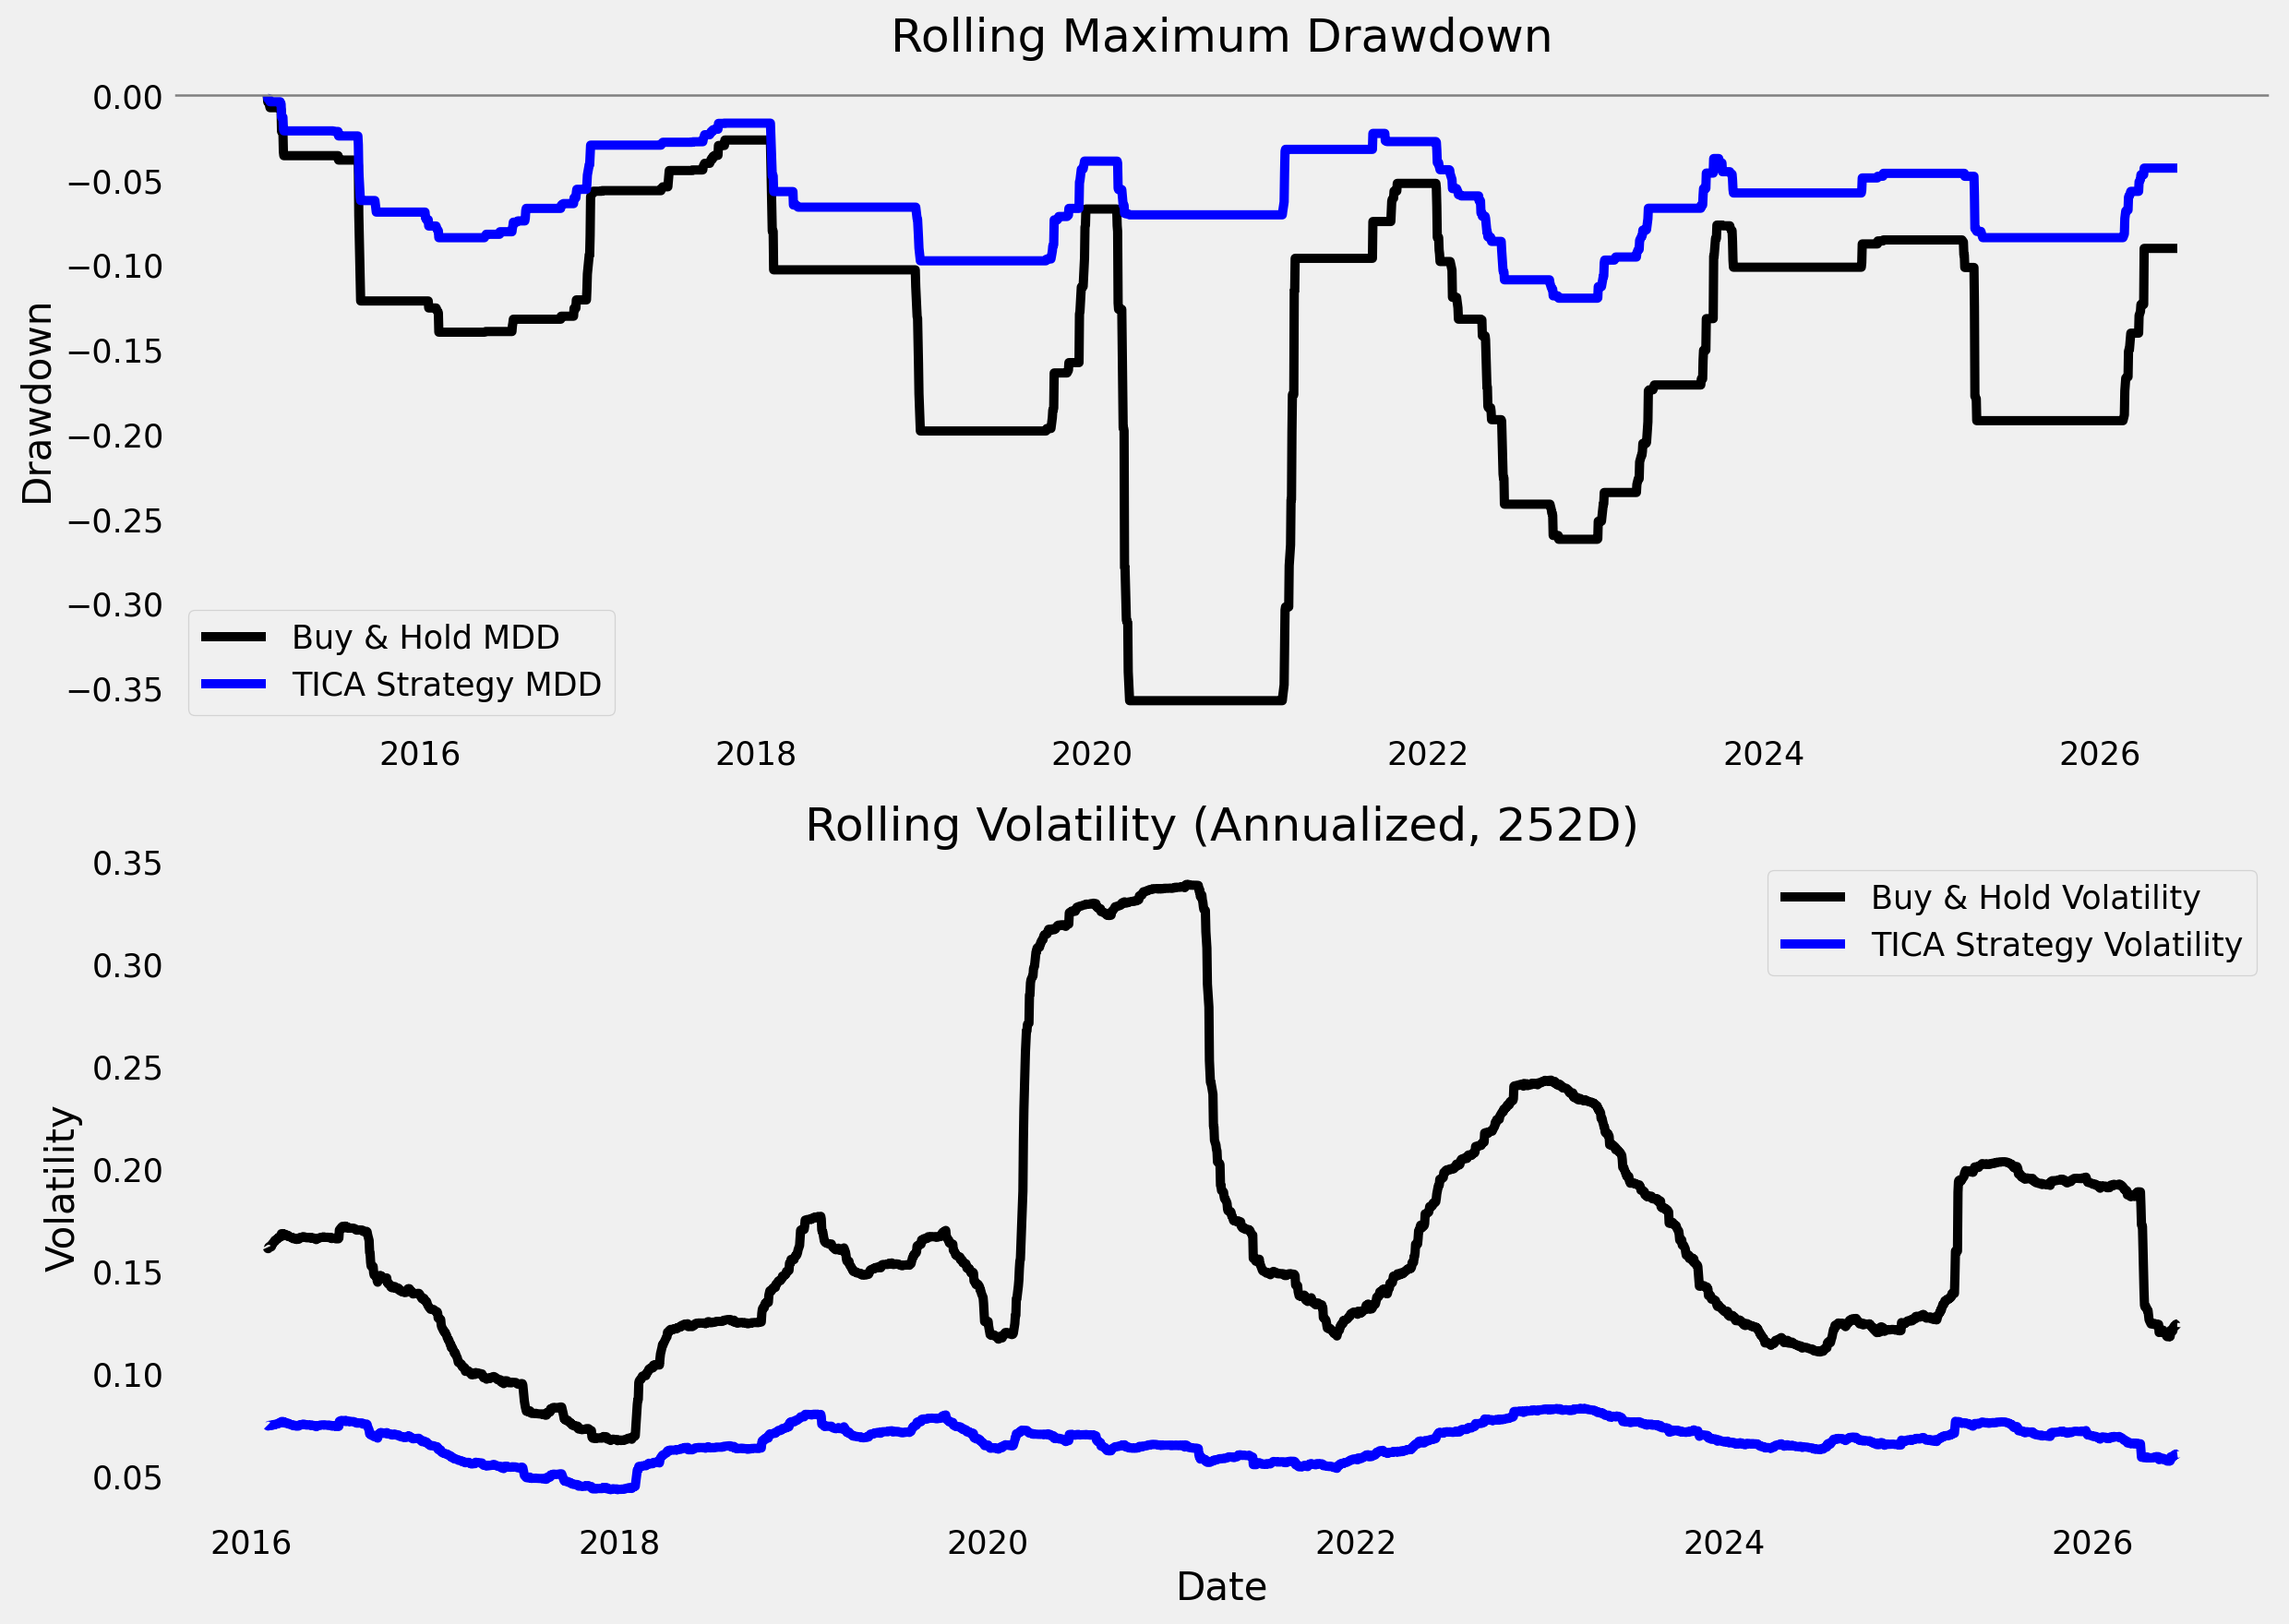

In [9]:
# -----------------------
# Rolling Max Drawdown
# -----------------------
def rolling_max_drawdown(equity, window=252):
  dd_list = []
  for i in range(len(equity)):
    start = max(0, i - window)
    window_equity = equity.iloc[start:i+1]
    peak = window_equity.cummax()
    dd = window_equity / peak - 1
    dd_list.append(dd.min())
  return pd.Series(dd_list, index=equity.index)

df["mdd_strategy"] = rolling_max_drawdown(df["equity_strategy"])
df["mdd_buyhold"] = rolling_max_drawdown(df["equity_buyhold"])

# -----------------------
# Rolling Volatility (252D annualized)
# -----------------------
def rolling_vol(r, window=252):
  return r.rolling(window).std() * np.sqrt(252)

df["vol_strategy"] = rolling_vol(df["strategy_ret"])
# Fixed: using 'market_ret' as defined in cell OIxu2_xUVCql
df["vol_buyhold"] = rolling_vol(df["market_ret"])

# -----------------------
# Plot (2 panels)
# -----------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Rolling Drawdown ---
axes[0].plot(df.index, df["mdd_buyhold"], label="Buy & Hold MDD", color="black")
axes[0].plot(df.index, df["mdd_strategy"], label="TICA Strategy MDD", color="blue")
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set_title("Rolling Maximum Drawdown")
axes[0].set_ylabel("Drawdown")
axes[0].grid()
axes[0].legend()

# --- Rolling Volatility ---
axes[1].plot(df.index, df["vol_buyhold"], label="Buy & Hold Volatility", color="black")
axes[1].plot(df.index, df["vol_strategy"], label="TICA Strategy Volatility", color="blue")
axes[1].set_title("Rolling Volatility (Annualized, 252D)")
axes[1].set_ylabel("Volatility")
axes[1].legend()
axes[1].grid()
plt.xlabel("Date")
plt.tight_layout()
plt.show()

#### **Hyperparameter Tuning**

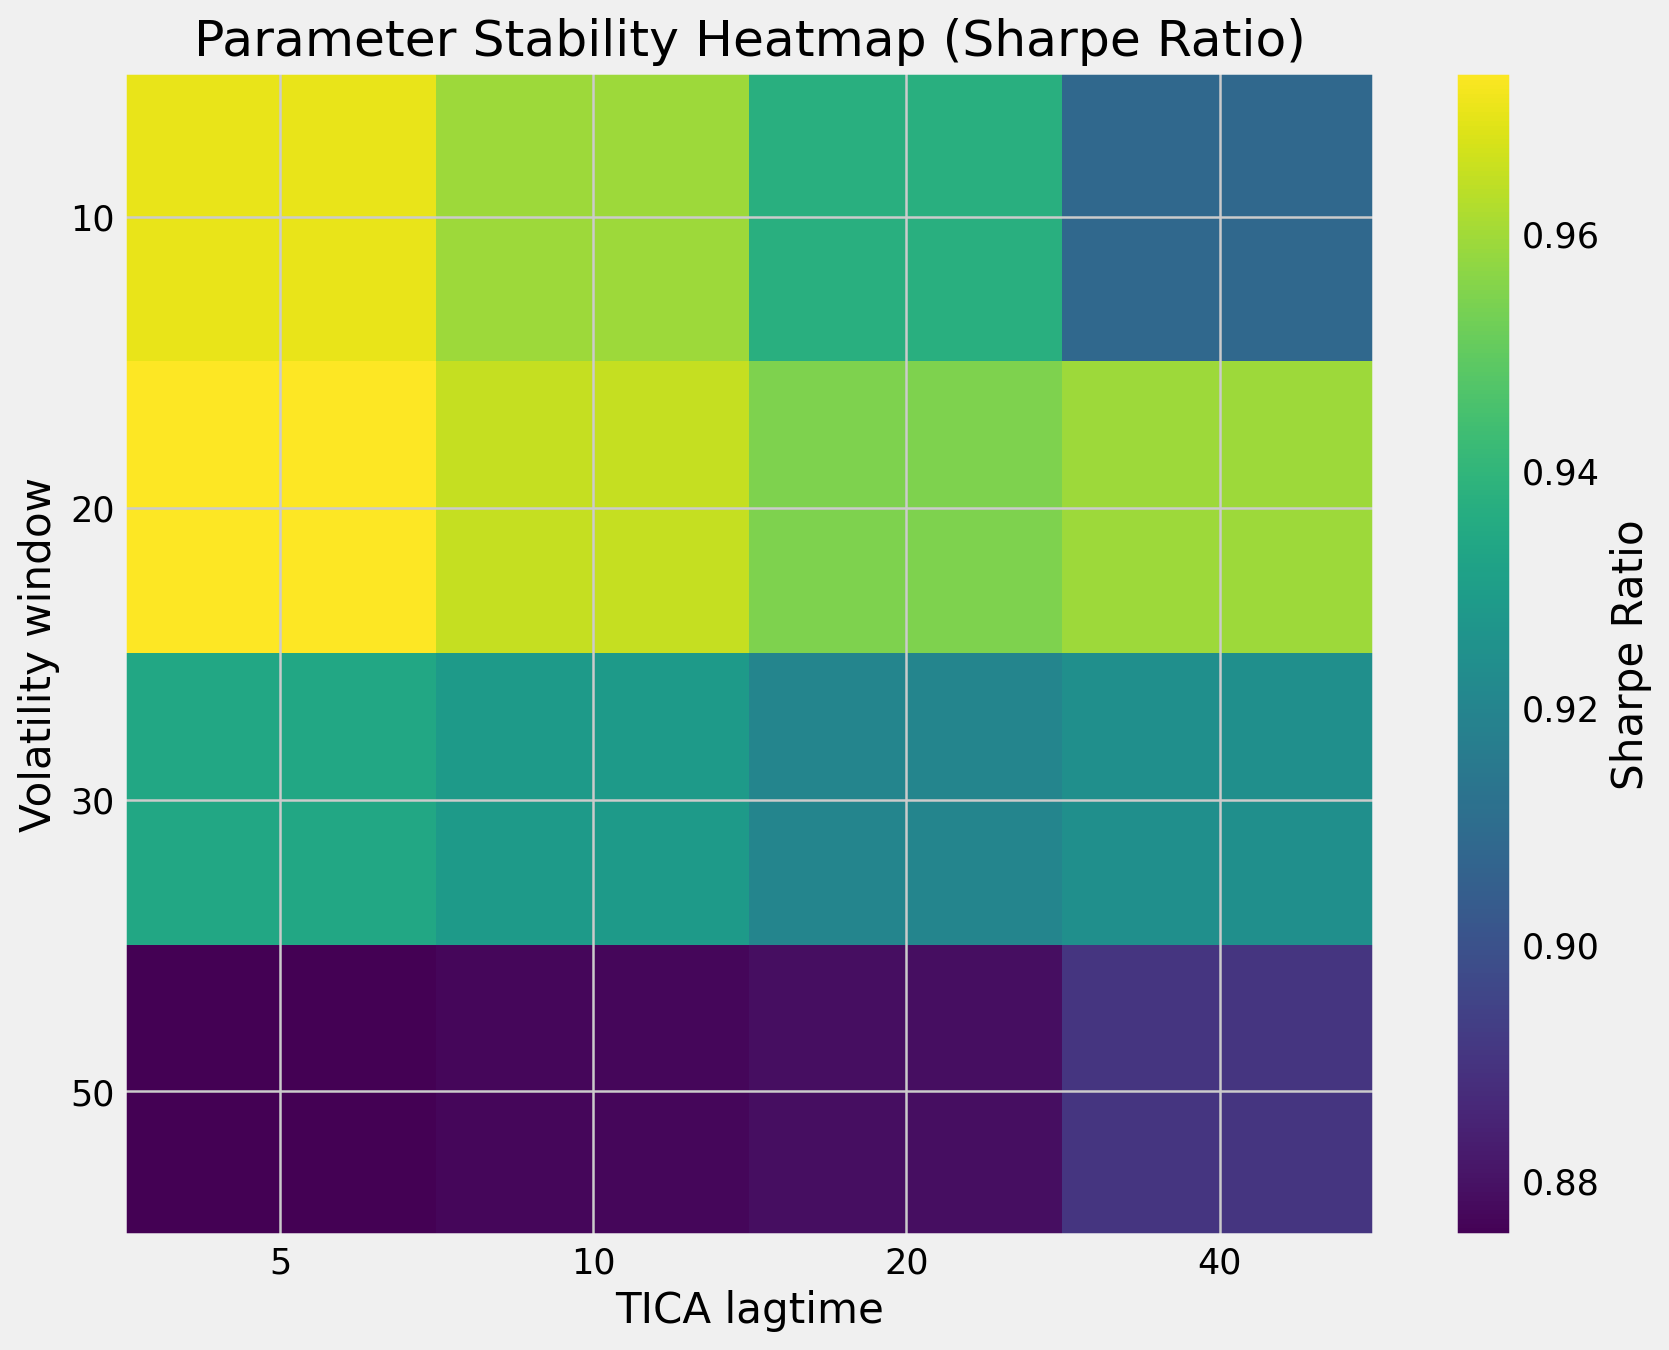

In [10]:
# -----------------------
# Sharpe function
# -----------------------
def sharpe(r):
  if r.std() == 0:
    return np.nan
  return np.sqrt(252) * r.mean() / r.std()

# Parameter grid
# -----------------------
lag_list = [5, 10, 20, 40]
vol_window_list = [10, 20, 30, 50]

results = pd.DataFrame(index=vol_window_list, columns=lag_list)

# -----------------------
# Grid search
# -----------------------
for vol_w in vol_window_list:
  df = df.copy()

  # features
  df["vol"] = df["ret"].rolling(vol_w).std()
  df["vix_chg"] = np.log(df["vix"]).diff()
  df = df.dropna()

  for lag in lag_list:
    try:
      X = df[["ret", "vix", "vix_chg", "vol"]].values
      X = (X - X.mean(axis=0)) / X.std(axis=0)

      # TICA
      tica = TICA(lagtime=lag, dim=1)
      tica_model = tica.fit_fetch(X)
      tic1 = tica_model.transform(X)[:, 0]

      tmp = df.iloc[-len(tic1):].copy()
      tmp["tic1"] = tic1

      # strategy
      tmp["position"] = 1 / (1 + np.exp(tmp["tic1"]))
      tmp["ret"] = np.log(tmp["price"]).diff()
      tmp = tmp.dropna()

      tmp["strategy_ret"] = tmp["position"].shift(1) * tmp["ret"]

      results.loc[vol_w, lag] = sharpe(tmp["strategy_ret"])

    except:
      results.loc[vol_w, lag] = np.nan

# -----------------------
# Plot heatmap
# -----------------------
plt.figure(figsize=(10,8))

plt.imshow(results.values.astype(float), cmap="viridis", aspect="auto")

plt.colorbar(label="Sharpe Ratio")

plt.xticks(
  ticks=np.arange(len(lag_list)),
  labels=lag_list
)

plt.yticks(
  ticks=np.arange(len(vol_window_list)),
  labels=vol_window_list
)

plt.xlabel("TICA lagtime")
plt.ylabel("Volatility window")
plt.title("Parameter Stability Heatmap (Sharpe Ratio)")

plt.show()

#### **Out-of-Sample Validation**

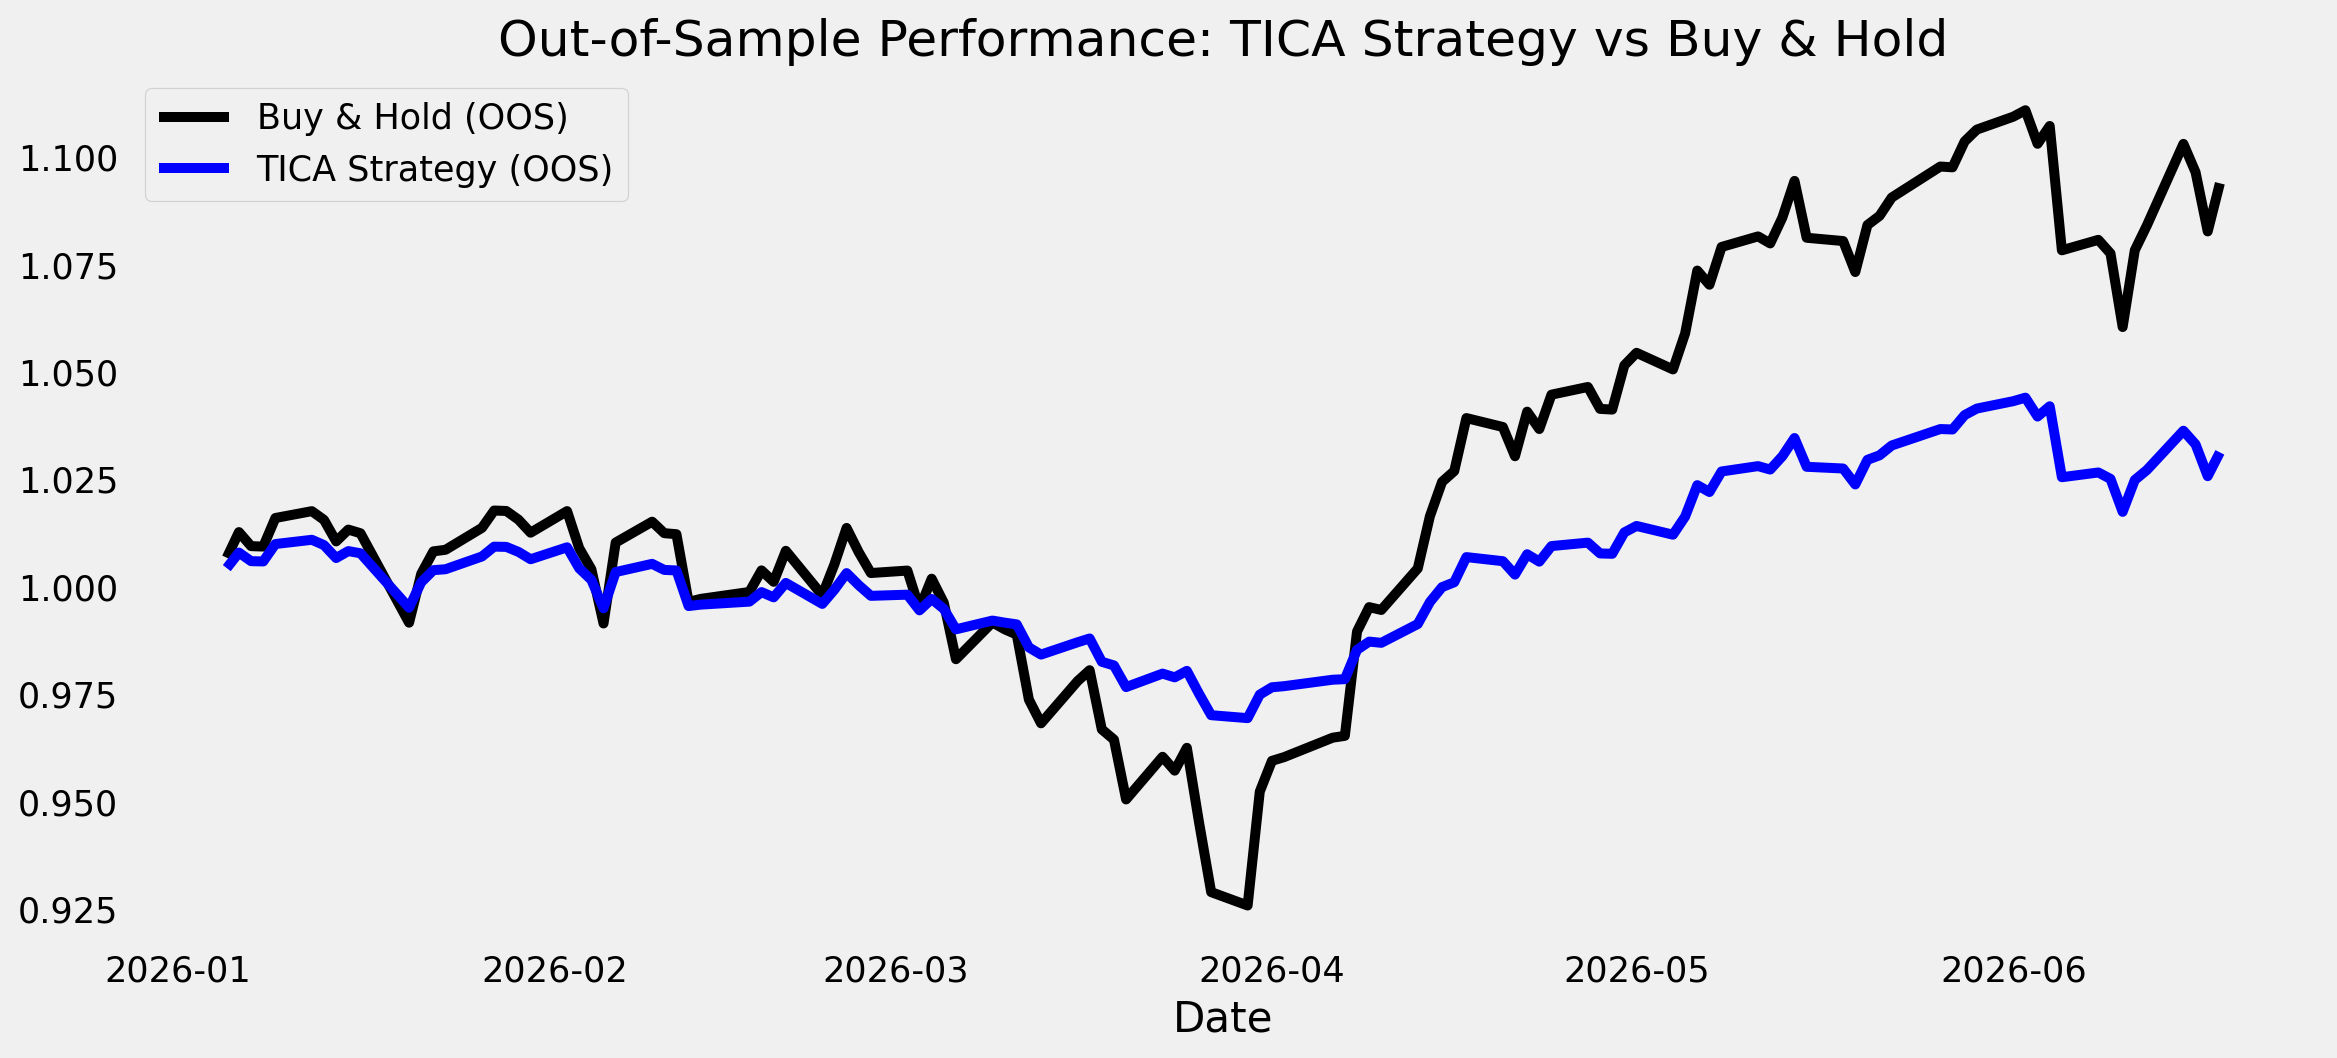

In [11]:
# -----------------------
# Load data
# -----------------------
spy = yf.download("SPY", start="2015-01-01", auto_adjust=True, progress=False)
vix = yf.download("^VIX", start="2015-01-01", auto_adjust=True, progress=False)

df = pd.DataFrame(index=spy.index)
df["price"] = spy["Close"]
df["vix"] = vix["Close"]

# -----------------------
# Returns
# -----------------------
df["ret"] = np.log(df["price"]).diff()

# -----------------------
# Features
# -----------------------
df["vol"] = df["ret"].rolling(20).std()
df["vix_chg"] = np.log(df["vix"]).diff()

df = df.dropna()

features = ["ret", "vix", "vix_chg", "vol"]

# -----------------------
# Train / Test split
# -----------------------
split_date = "2026-01-01"

train = df.loc[:split_date].copy()
test = df.loc[split_date:].copy()

# -----------------------
# Fit scaling ONLY on train
# -----------------------
X_train = train[features].values
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0) + 1e-8

X_train_scaled = (X_train - mu) / sigma
X_test_scaled = (test[features].values - mu) / sigma

# -----------------------
# Fit TICA ONLY on train
# -----------------------
tica = TICA(lagtime=20, dim=1)
tica_model = tica.fit_fetch(X_train_scaled)

# -----------------------
# Transform both train and test
# -----------------------
train["tic1"] = tica_model.transform(X_train_scaled)[:, 0]
test["tic1"] = tica_model.transform(X_test_scaled)[:, 0]

# -----------------------
# Normalize TIC1 using TRAIN stats ONLY
# -----------------------
tic_mean = train["tic1"].mean()
tic_std = train["tic1"].std() + 1e-8

train["tic1_z"] = (train["tic1"] - tic_mean) / tic_std
test["tic1_z"] = (test["tic1"] - tic_mean) / tic_std

# -----------------------
# Strategy rule
# -----------------------
for d in [train, test]:
    d["position"] = 1 / (1 + np.exp(d["tic1_z"]))
    d["strategy_ret"] = d["position"].shift(1) * d["ret"]
    d["buyhold_ret"] = d["ret"]

train = train.dropna()
test = test.dropna()

# -----------------------
# Equity curves
# -----------------------
train["eq_strategy"] = (1 + train["strategy_ret"]).cumprod()
train["eq_buyhold"] = (1 + train["buyhold_ret"]).cumprod()

test["eq_strategy"] = (1 + test["strategy_ret"]).cumprod()
test["eq_buyhold"] = (1 + test["buyhold_ret"]).cumprod()

# -----------------------
# Plot ONLY OOS
# -----------------------
plt.figure(figsize=(14,6))

plt.plot(test.index, test["eq_buyhold"], label="Buy & Hold (OOS)", color="black")
plt.plot(test.index, test["eq_strategy"], label="TICA Strategy (OOS)", color="blue")

plt.title("Out-of-Sample Performance: TICA Strategy vs Buy & Hold")
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.show()

In [12]:
# -----------------------
# Metrics functions
# -----------------------
def sharpe(r):
  return np.sqrt(252) * r.mean() / (r.std() + 1e-8)

def sortino(r):
  downside = r[r < 0]
  return np.sqrt(252) * r.mean() / (downside.std() + 1e-8)

def max_drawdown(equity):
  peak = equity.cummax()
  dd = equity / peak - 1
  return dd.min()

def cagr(equity):
  years = len(equity) / 252
  return equity.iloc[-1] ** (1 / years) - 1

def volatility(r):
  return np.sqrt(252) * r.std()

# -----------------------
# ASSUMPTION:
# We already ran OOS code and have:
# test["strategy_ret"]
# test["buyhold_ret"]
# test["eq_strategy"]
# test["eq_buyhold"]
# -----------------------

# Strategy metrics
strategy = {
  "CAGR": cagr(test["eq_strategy"]),
  "Sharpe": sharpe(test["strategy_ret"]),
  "Sortino": sortino(test["strategy_ret"]),
  "Volatility": volatility(test["strategy_ret"]),
  "Max Drawdown": max_drawdown(test["eq_strategy"]),
}

# Buy & Hold metrics
buyhold = {
  "CAGR": cagr(test["eq_buyhold"]),
  "Sharpe": sharpe(test["buyhold_ret"]),
  "Sortino": sortino(test["buyhold_ret"]),
  "Volatility": volatility(test["buyhold_ret"]),
  "Max Drawdown": max_drawdown(test["eq_buyhold"]),
}

# -----------------------
# Build comparison table
# -----------------------
results = pd.DataFrame([strategy, buyhold], index=["TICA Strategy (OOS)", "Buy & Hold (OOS)"])
display(results)

,CAGR,Sharpe,Sortino,Volatility,Max Drawdown
TICA Strategy (OOS),0.0696,1.0746,1.3811,0.0645,-0.0411
Buy & Hold (OOS),0.2171,1.4521,2.1037,0.1423,-0.0903


#### **Kelly Leverage Optimization**

In [13]:
# -----------------------
# Kelly estimator
# -----------------------
def kelly_fraction(r):
  mu = r.mean()
  var = r.var()
  if var == 0:
    return 0
  return mu / var

# -----------------------
# Compute Kelly for OOS series
# -----------------------
kelly_strategy = kelly_fraction(test["strategy_ret"])
kelly_buyhold = kelly_fraction(test["buyhold_ret"])

print("Raw Kelly (Strategy):", kelly_strategy)
print("Raw Kelly (Buy & Hold):", kelly_buyhold)

Raw Kelly (Strategy): 16.656191109870814
Raw Kelly (Buy & Hold): 10.206698867847967


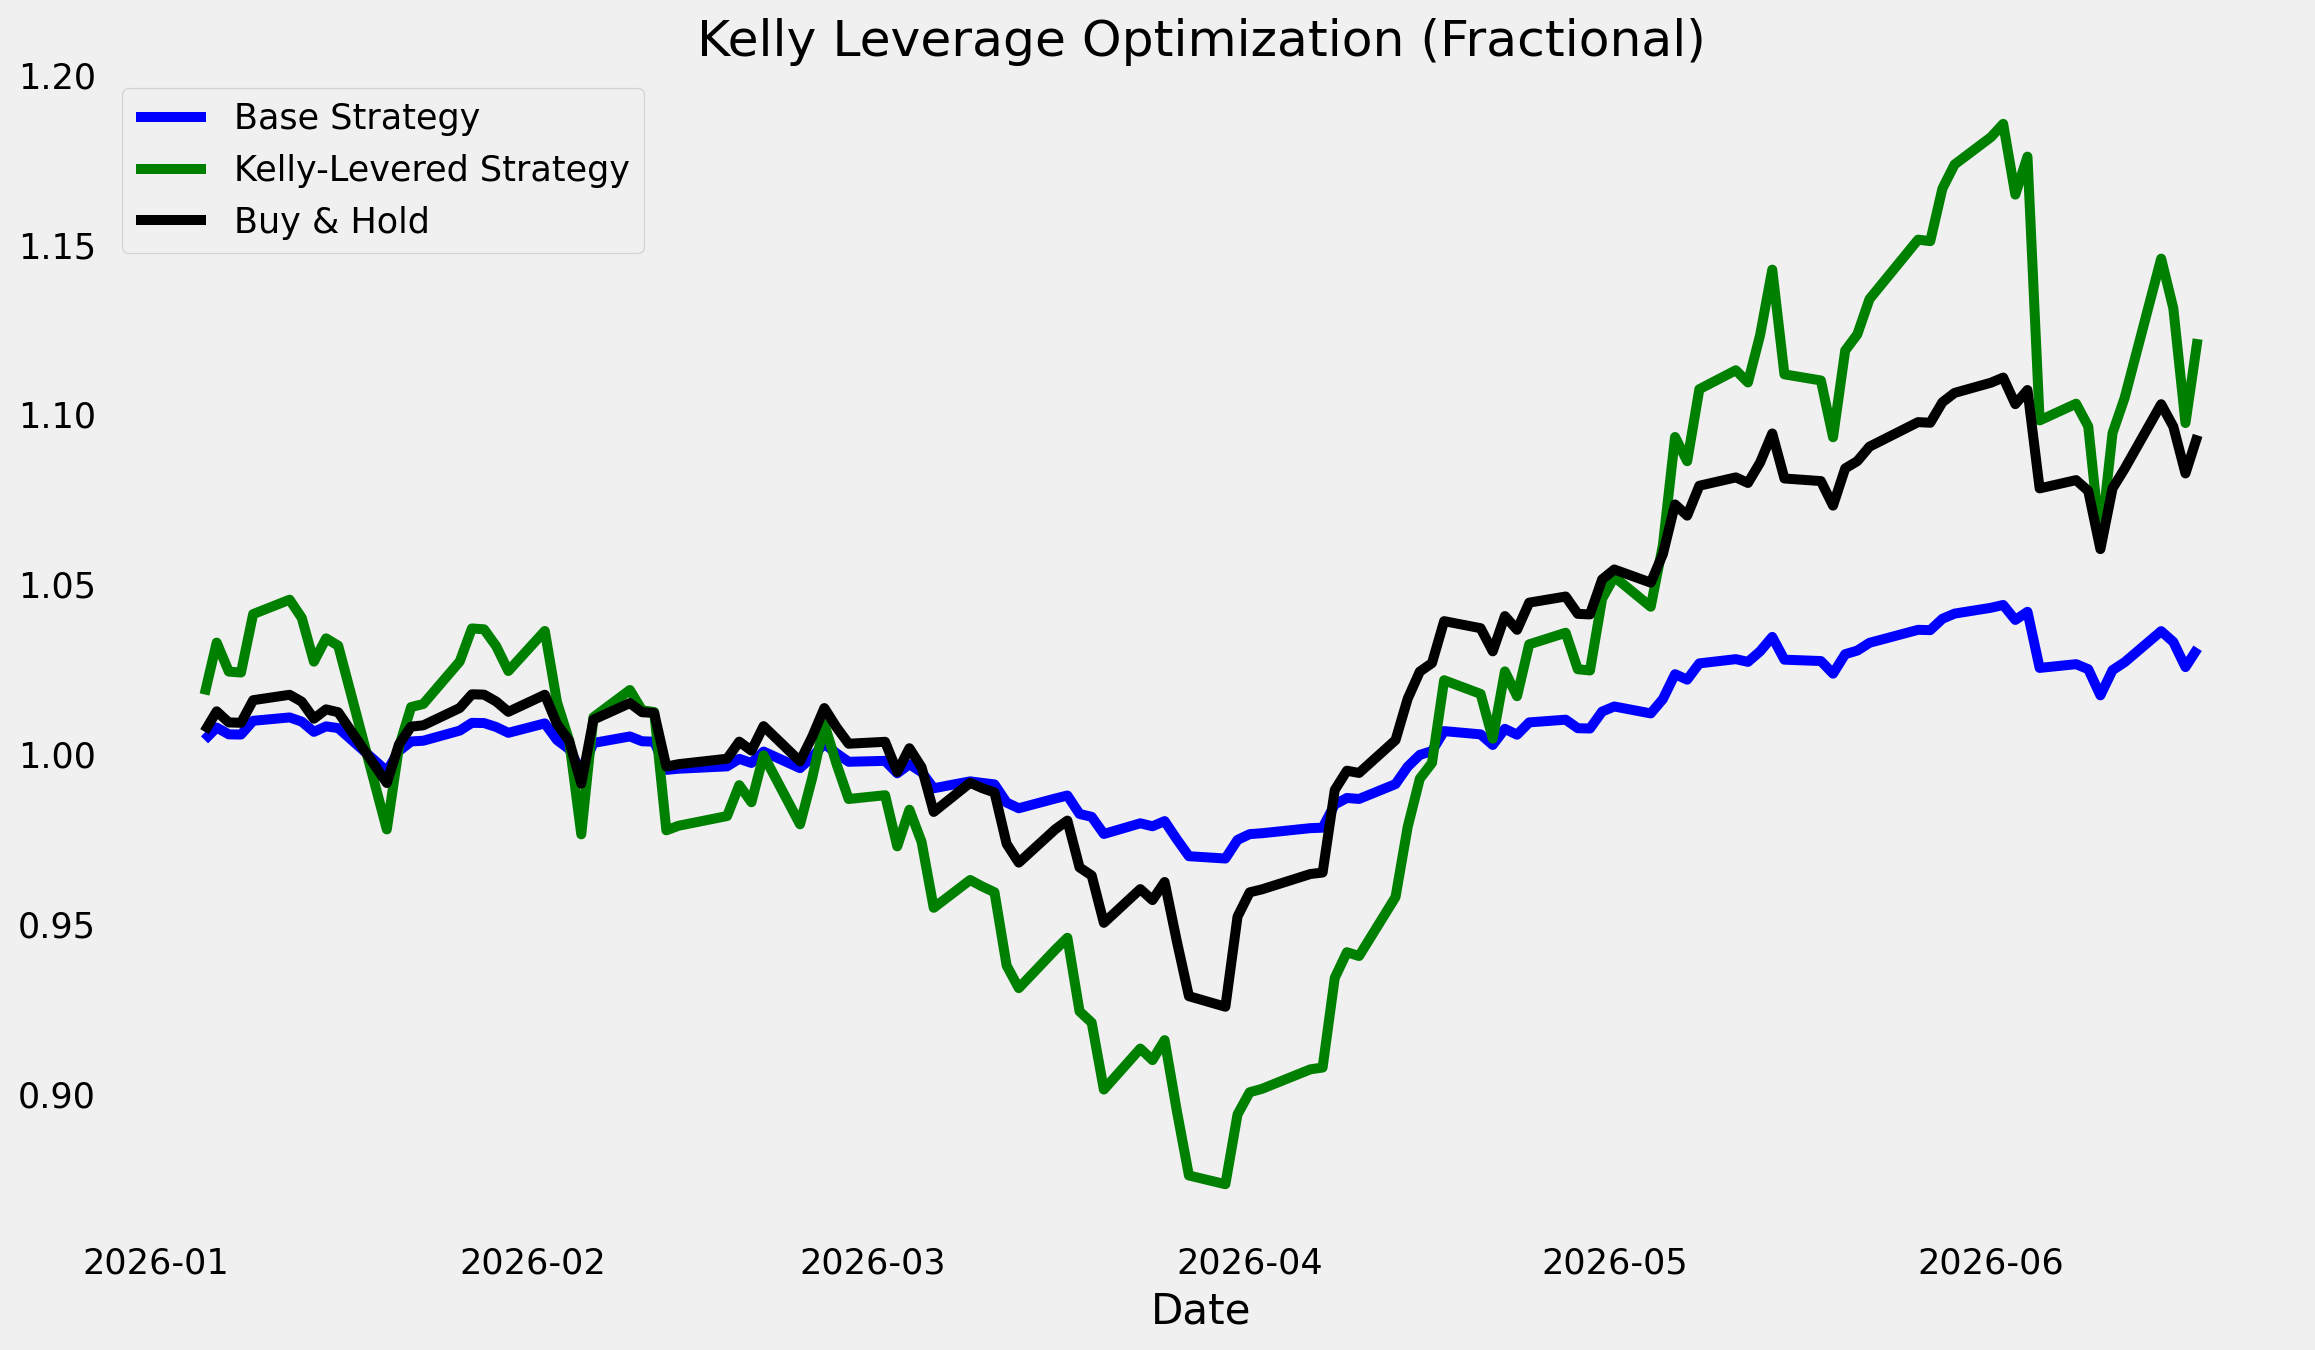

In [14]:
fraction = 0.25  # fractional Kelly (safe default)

test["kelly_leverage"] = kelly_strategy * fraction

# Apply leverage
test["levered_strategy_ret"] = test["strategy_ret"] * test["kelly_leverage"]

test["equity_levered"] = (1 + test["levered_strategy_ret"]).cumprod()

# Plotting
plt.figure(figsize=(14, 8))

plt.plot(test.index, test["eq_strategy"], label="Base Strategy", color="blue")
plt.plot(test.index, test["equity_levered"], label="Kelly-Levered Strategy", color="green")
plt.plot(test.index, test["eq_buyhold"], label="Buy & Hold", color="black")

plt.title("Kelly Leverage Optimization (Fractional)")
plt.legend()
plt.xlabel("Date")
plt.grid()
plt.show()

Kelly leverage: 2.0


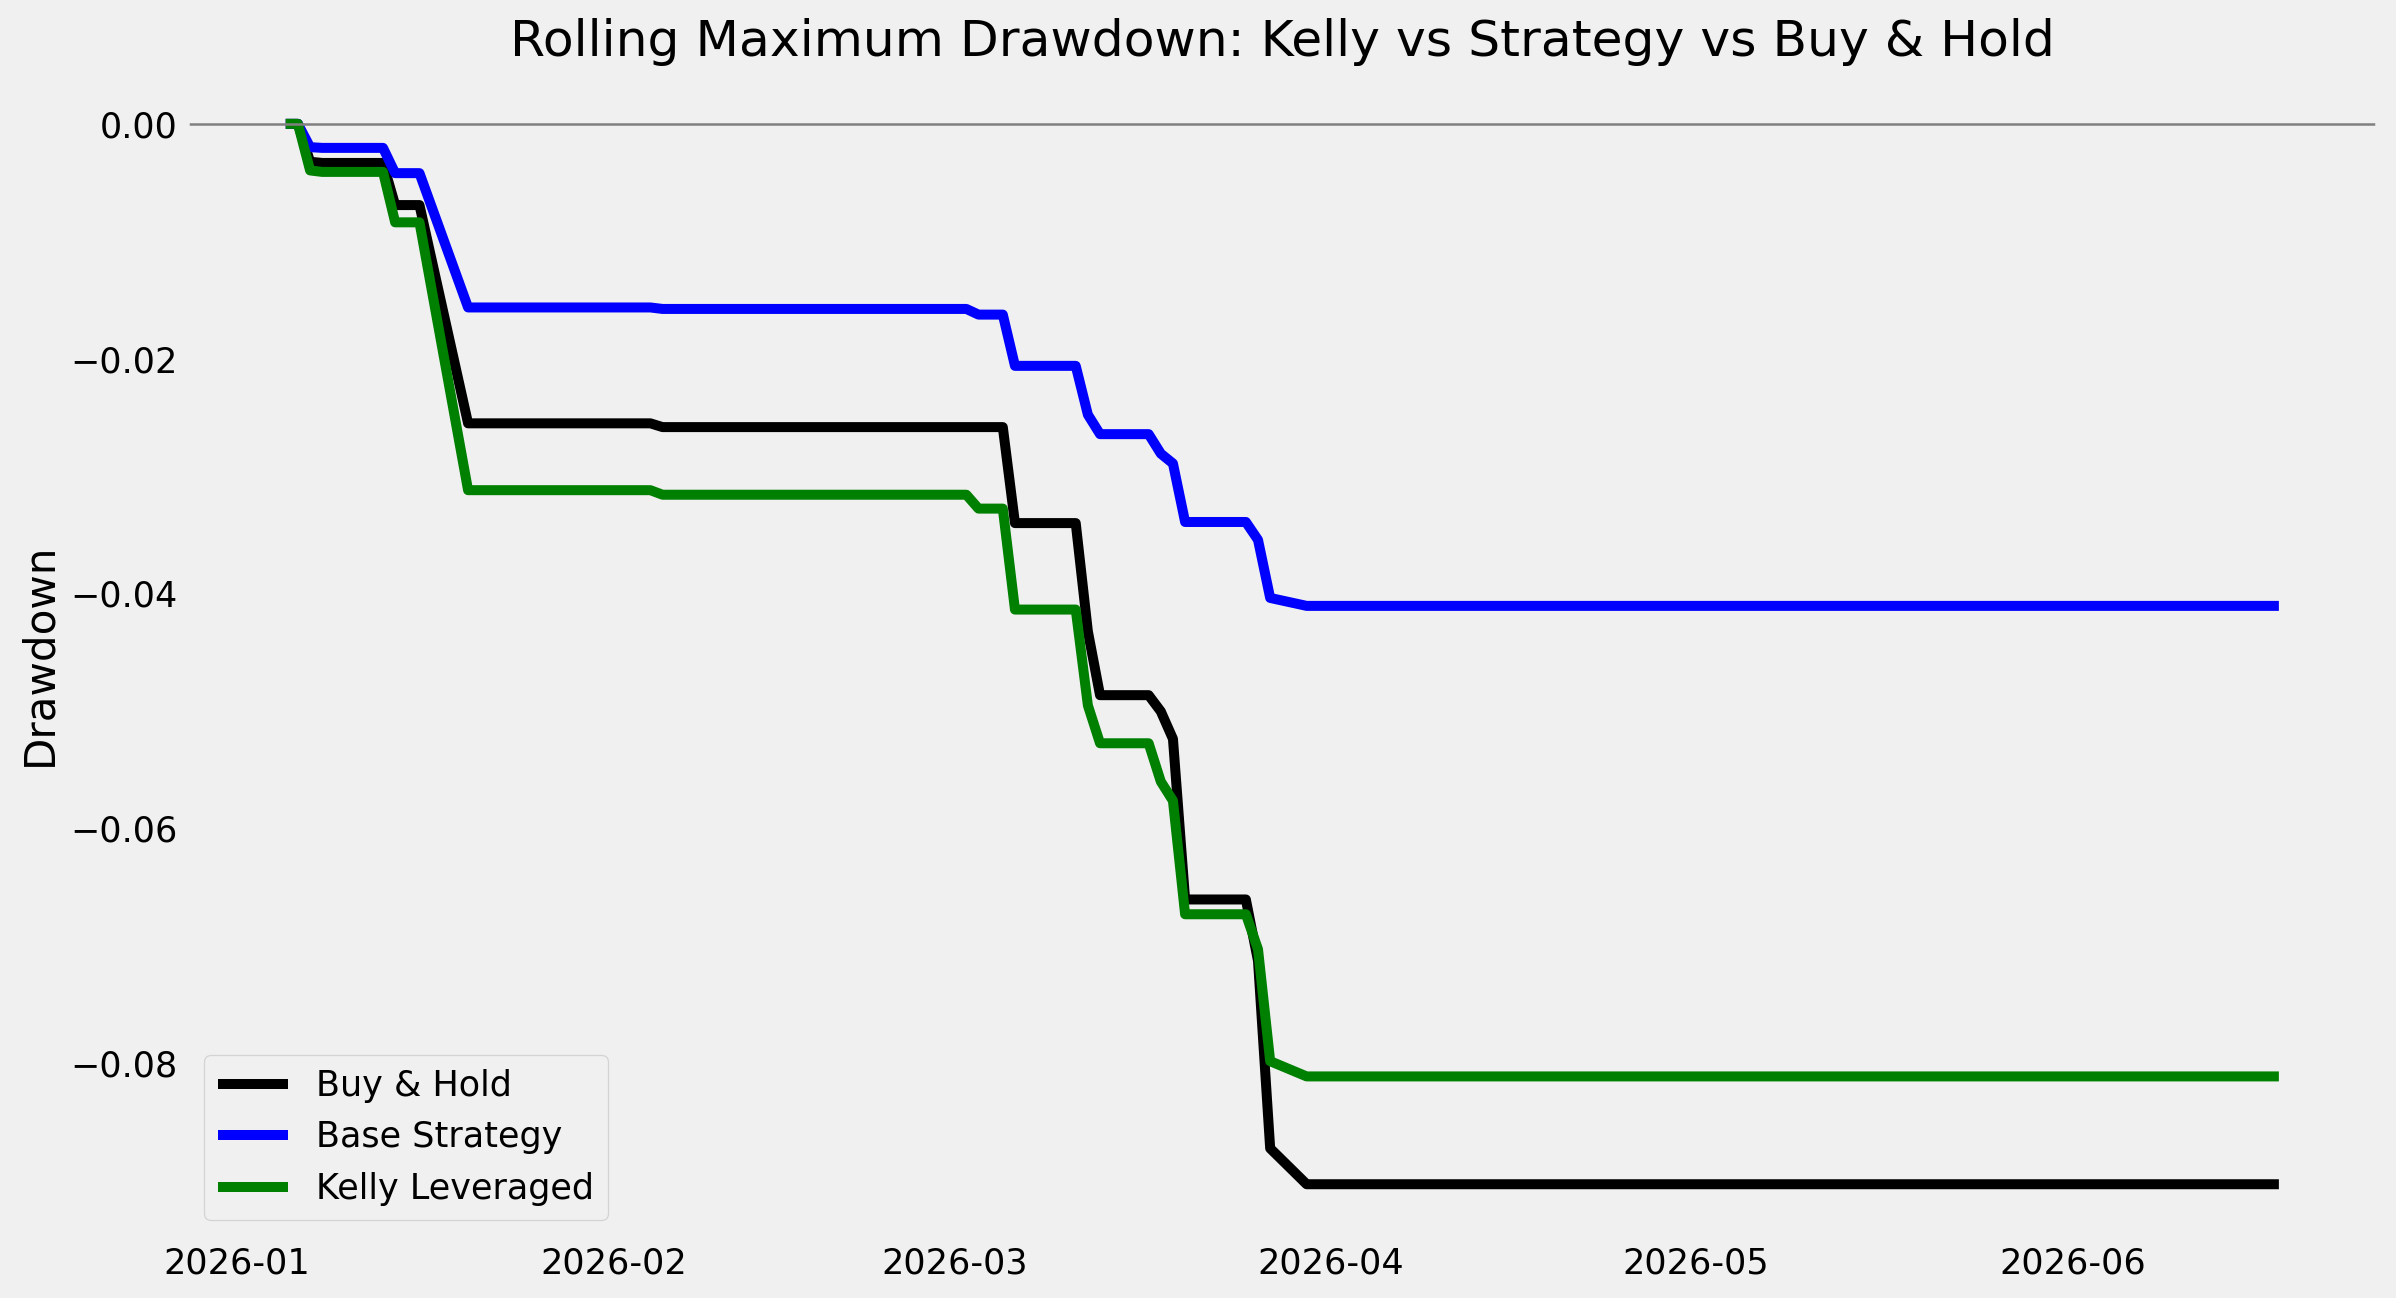

In [15]:
def kelly_fraction(r):
    mu = r.mean()
    var = r.var()
    return mu / (var + 1e-8)

kelly_raw = kelly_fraction(test["strategy_ret"])
kelly = np.clip(0.25 * kelly_raw, 0, 2)  # fractional + safety cap

print("Kelly leverage:", kelly)

test = test.copy()

test["kelly_ret"] = test["strategy_ret"] * kelly
test["equity_kelly"] = (1 + test["kelly_ret"]).cumprod()

#Rolling drawdown

def rolling_drawdown(equity, window=252):
    dd_list = []

    for i in range(len(equity)):
        start = max(0, i - window)
        window_eq = equity.iloc[start:i+1]

        peak = window_eq.cummax()
        dd = window_eq / peak - 1
        dd_list.append(dd.min())

    return pd.Series(dd_list, index=equity.index)

test["mdd_kelly"] = rolling_drawdown(test["equity_kelly"])
test["mdd_base"] = rolling_drawdown((1 + test["strategy_ret"]).cumprod())
test["mdd_buyhold"] = rolling_drawdown((1 + test["buyhold_ret"]).cumprod())

plt.figure(figsize=(14,8))

plt.plot(test.index, test["mdd_buyhold"], label="Buy & Hold", color="black")
plt.plot(test.index, test["mdd_base"], label="Base Strategy", color="blue")
plt.plot(test.index, test["mdd_kelly"], label="Kelly Leveraged", color="green")

plt.axhline(0, color="gray", linewidth=1)

plt.title("Rolling Maximum Drawdown: Kelly vs Strategy vs Buy & Hold")
plt.ylabel("Drawdown")
plt.grid()
plt.legend()
plt.show()

#### **deeptime Logo Visualization**

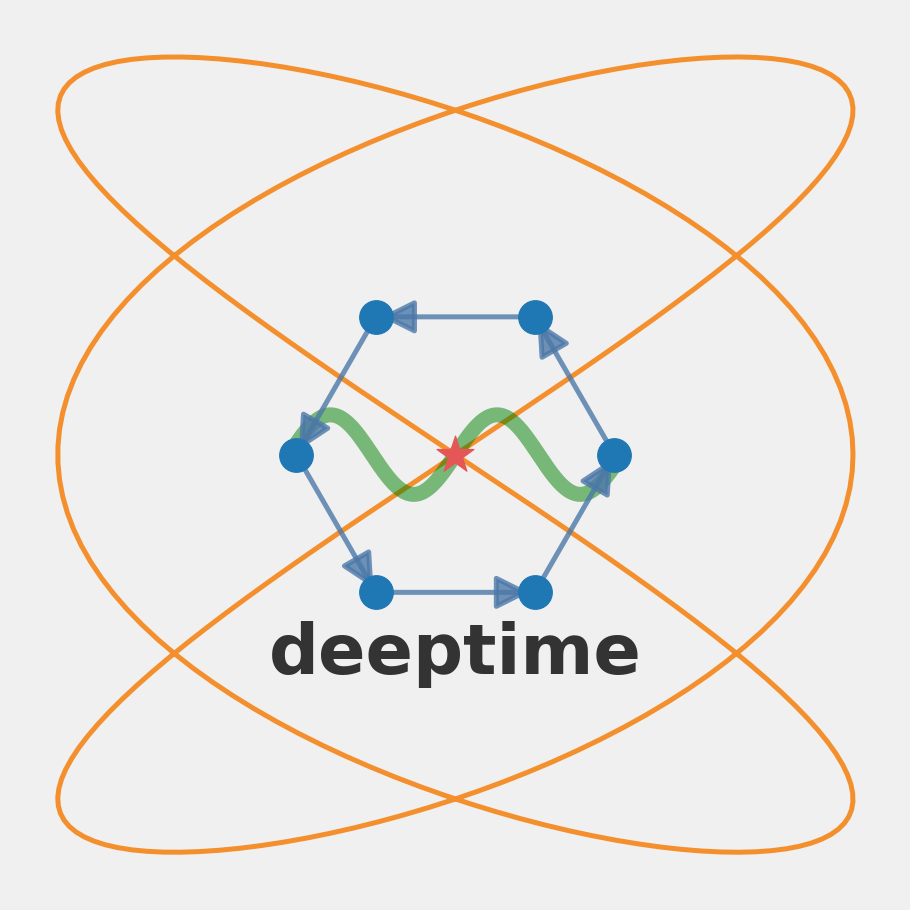

In [16]:
# -----------------------------
# Figure setup (logo style)
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axis("off")

# -----------------------------
# 1. Outer Markov loop (states)
# -----------------------------
n_states = 6
theta = np.linspace(0, 2*np.pi, n_states, endpoint=False)

R = 1.0
nodes = np.c_[R*np.cos(theta), R*np.sin(theta)]

# draw circular arrows (Markov transitions)
for i in range(n_states):
  start = nodes[i]
  end = nodes[(i + 1) % n_states]

  ax.annotate(
    "",
    xy=end, xytext=start,
    arrowprops=dict(
        arrowstyle="-|>",
        lw=2,
        color="#4C78A8",
        alpha=0.8,
        mutation_scale=28  # 👈 controls arrow head size
    )
  )
# nodes
ax.scatter(nodes[:,0], nodes[:,1],
           s=180, color="#1F77B4", zorder=5)

# -----------------------------
# 2. Latent "slow mode" core
# -----------------------------
t = np.linspace(0, 2*np.pi, 300)
x = 2.5 * np.cos(3*t)
y = 2.5 * np.sin(2*t)

ax.plot(x, y, color="#F58518", lw=2, alpha=0.9)

# central equilibrium point
ax.scatter([0], [0], s=240, color="#E45756", marker="*", zorder=15)

# -----------------------------
# 3. Time-flow hint (gradient line)
# -----------------------------
x_line = np.linspace(-1.0, 1.0, 200)
y_line = 0.25 * np.sin(6*x_line)

ax.plot(x_line, y_line, color="green", lw=6, alpha=0.5)

# -----------------------------
# 4. Title (optional logo text)
# -----------------------------
ax.text(0, -1.25, "deeptime",
    ha="center",
    va="center",
    fontsize=28,
    fontweight="bold",
    color="#333333")

# -----------------------------
# Save vector outputs
# -----------------------------
if not IN_COLAB:
  plt.savefig("deeptime_logo.svg", format="svg", bbox_inches="tight")
  plt.savefig("deeptime_logo.pdf", format="pdf", bbox_inches="tight")
  plt.savefig("deeptime_logo.png", format="png", bbox_inches="tight")

plt.show()